# Evaluation Plots

Vision: 

```
from ocean_emulators.plotting import eval_plots

training_url = ...
prediction_url = ...

eval_plots(training_url, prediction_url)
```

Where

```
def eval_plots(...):
    # Run tests on prediction data
    # Plot all relevant panels in a neat and organized way
```


### Imports

In [33]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
from xarrayutils.plotting import linear_piecewise_scale
from dask.diagnostics import ProgressBar
from datetime import datetime

### Utils

In [34]:
import sys
sys.path.append("../ocean_emulators_main/")

from ocean_emulators.dataset_validation import ds_input_validate, ds_prediction_validate
from ocean_emulators.postprocessing import post_processor

### Data

In [35]:

def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here
    # try:
    #     ds_input_validate(ds_truth, deep=False)
    # except ValueError as e:
    #     raise ValueError(
    #         f"Checking the input dataset failed with {e}. Please fix those issues before creating a postprocessed dataset."
    #     )

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})
        warnings.warn(
            "Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream"
        )
    key = list(ds.variables.keys())[0]
    da = ds[key]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    elif set(ls) - {"zos"} == set(["thetao"]):
        variables = ["thetao"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    if "zos" in ls:
        variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})
    ds_out.attrs = ds.attrs

    return ds_out


In [36]:
##### Paths
# Modes - onlytemp, TS, slow, all

pred_dict = {
    "pred_1": {
        "mode": "slow",
        "name": "Thermo Swin Hist 1 Epoch 67",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-28_SwinCM4Hist1NofastinoutEpochs70Epoch67_Train_global_3D_Test_global_3D_all_N_train_13800_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_13800_rand_seed_1.zarr"
    },
    "pred_2": {
        "mode": "slow",
        "name": "Thermo Hist 1 Epoch 55",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-22_ConvNextUNetCM4Hist1NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_13800_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_13800_rand_seed_1.zarr"
    }
}

prefix_path="CM4"

clist = ["#ff807a","#1e8685","#ffb579","#63c8ab"]

# Rollout details
levels = 19

In [37]:
import os
import json
import pandas as pd
import copy
import fsspec

# CM4
fs_osn = fsspec.filesystem(
    's3',
    profile='ocean_emulator',  ## This is the profile name you configured above.
)
mapper = fs_osn.get_mapper("emulators/jbusecke/ocean-emulators/CM4_5daily_v0.4.0.zarr")
ds_input = xr.open_zarr(mapper, consolidated=True)
ds_input = ds_input.drop_vars(['lat_b', 'lon_b'])

# ds_input_validate(ds_input)
ds_groundtruth = ds_input.isel(time=slice(13941, 13941+600)).isel(lev=slice(None, levels))
ds_groundtruth = ds_groundtruth.astype('float32')

output_path = "../outputs/" + str(datetime.now())[:10] + '_' + prefix_path + '_' + '_'.join([pred_dict[k]["name"] for k in pred_dict.keys()])
print("Using Output Folder : ", output_path)
if not os.path.isdir(os.path.join(output_path)):
    os.makedirs(os.path.join(output_path))
    
compare_info_dict = copy.deepcopy(pred_dict)
    
for k in pred_dict.keys():
    if pred_dict[k]['mode'] == 'slow':
        pred_dict[k]["ls"] = ['thetao', 'so', 'zos']
    elif pred_dict[k]['mode'] == 'onlytemp':
        pred_dict[k]["ls"] = ['thetao']
    elif pred_dict[k]['mode'] == 'TS':
        pred_dict[k]["ls"] = ['thetao', 'so']
    else:
        pred_dict[k]["ls"] = ['uo', 'vo', 'thetao', 'so', 'zos']


    Pred_path = pred_dict[k]['path']
    ds_prediction_raw = xr.open_zarr(Pred_path)
    ds_prediction = post_processor(
        ds_prediction_raw, ds_groundtruth, pred_dict[k]["ls"]
    )

    ds_prediction_validate(ds_prediction)
    pred_dict[k]["ds_prediction"] = ds_prediction
    
    if 'model_path' in ds_prediction.attrs:
        compare_info_dict[k]["model_path"] = ds_prediction.attrs['model_path']
        
with open(os.path.join(output_path, 'compare_info.txt'), 'w') as f:
    f.write(json.dumps(compare_info_dict, sort_keys=True, indent=4))

Using Output Folder :  ../outputs/2024-11-28_CM4_Thermo Swin Hist 1 Epoch 67_Thermo Hist 1 Epoch 55


/tmp/ipykernel_768867/4086450380.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing yet
  warnings.warn("This checks nothing yet")
/tmp/ipykernel_768867/4086450380.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing yet
  warnings.warn("This checks nothing yet")


In [38]:
%matplotlib inline

In [39]:
def profile_mean(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(["x", "y"])

def profile_std(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).std(["x", "y"])

def full_std(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello*ds.dz).std(["x", "y","lev"]).mean("time")

In [40]:
with ProgressBar():
    print("Ground truth CM4")
    ds_groundtruth = ds_groundtruth.assign(KE=0.5 * (ds_groundtruth.uo ** 2 + ds_groundtruth.vo ** 2)*1020)
    profile_groundtruth = profile_mean(ds_groundtruth).load()
    
    for k in pred_dict.keys():
        print(k)
        if 'uo' in pred_dict[k]["ls"]:
            pred_dict[k]["ds_prediction"] = pred_dict[k]["ds_prediction"].assign(KE=0.5 * (pred_dict[k]["ds_prediction"].uo ** 2 + pred_dict[k]["ds_prediction"].vo ** 2)*1020)
            pred_dict[k]["ls"].append('KE')
        pred_dict[k]["profile_prediction"] = profile_mean(pred_dict[k]["ds_prediction"]).load()

Ground truth CM4
[########################################] | 100% Completed | 58.97 s
pred_1
[########################################] | 100% Completed | 11.34 s
pred_2
[########################################] | 100% Completed | 11.68 s


In [41]:
var_list = {
        "vo": r"$v$ $( m/s )$",
        "uo": r"$u$ $( m/s )$",
        "thetao": r"$T$ $( ^\circ C )$",
        "so": r"$so$ $( psu )$",
        "zos": r"$zos$ $( m )$",
        "KE": r"$KE$ $( J/m^2 )$",
    }

### Timeseries analysis

In [42]:
### Plotting timeseries for each variable for each level
for v in ['uo', 'vo', 'thetao', 'so', 'zos', 'KE']:
    if not os.path.isdir(os.path.join(output_path, f"{v}_timeseries")):
        os.makedirs(os.path.join(output_path, f"{v}_timeseries"))
    
    plt.clf()
    plt.rcParams.update({'font.size': 20})
    plt.figure(figsize=[18, 10])
    
    if v == 'zos':
        profile_groundtruth[v].plot(label='CM4', c='k')
        for i, k in enumerate(pred_dict.keys()):
            if v in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][v].plot(label=pred_dict[k]["name"], c=clist[i])
        min_val, max_val = plt.ylim()
        plt.ylim(min_val - 0.05, max_val + 0.05)
        plt.xlabel('Time')
        plt.ylabel(var_list[v])
        plt.legend()
        plt.savefig(os.path.join(output_path, f"{v}_timeseries/0.png"), bbox_inches='tight', dpi=600)
        plt.close()
    else:
        for lev in range(levels):
            plt.clf()
            plt.rcParams.update({'font.size': 20})
            plt.figure(figsize=[18, 10])
            profile_groundtruth[v].isel(lev=lev).plot(label='CM4', c='k')
            min_val, max_val = plt.ylim()
            for i, k in enumerate(pred_dict.keys()):
                if v in pred_dict[k]["ls"]:
                    pred_dict[k]["profile_prediction"][v].isel(lev=lev).plot(label=pred_dict[k]["name"], c=clist[i])
            if v == 'thetao':
                plt.ylim(min_val - 0.25, max_val + 0.25)
            elif v == 'so':
                plt.ylim(min_val - 0.2, max_val + 0.2)
            elif v == 'KE':
                plt.ylim(min_val - 0.5, max_val + 0.5)
            
            plt.xlabel('Time')
            plt.ylabel(var_list[v])
            plt.legend()       
            plt.savefig(os.path.join(output_path, f"{v}_timeseries/{lev}.png"), bbox_inches='tight', dpi=600)
            plt.close()

<Figure size 640x480 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

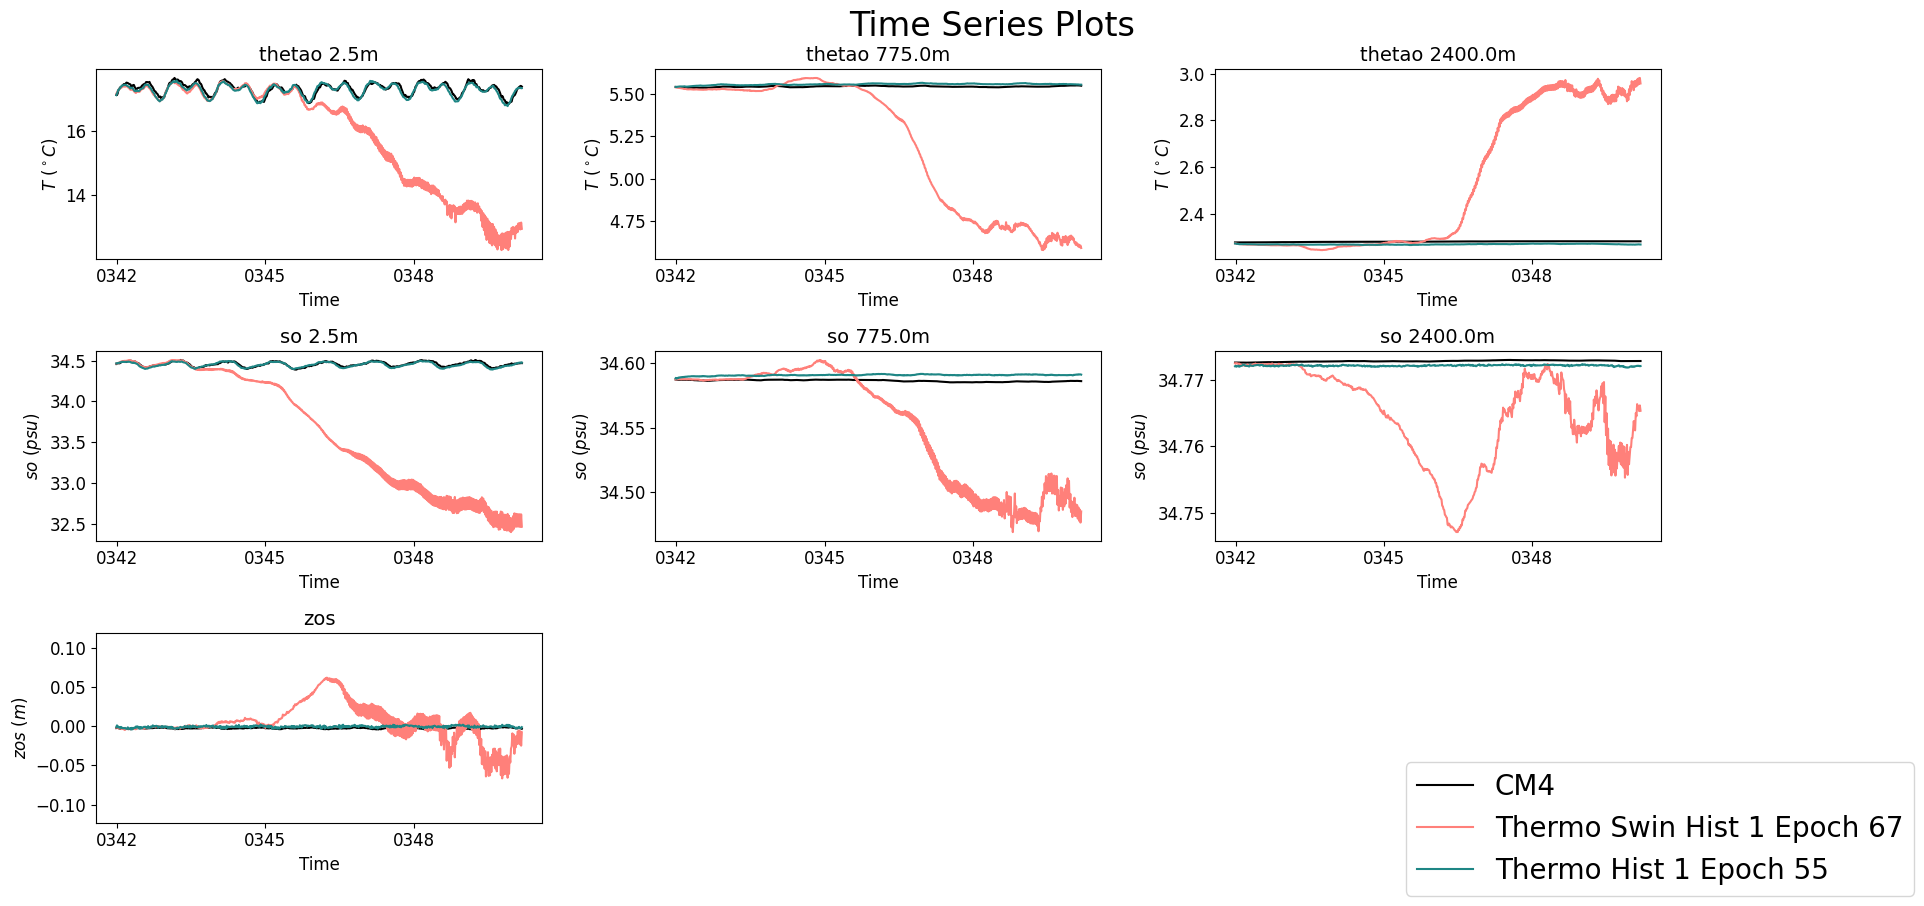

In [43]:
import matplotlib.pyplot as plt
import os

shallow_levels = [2.5, 775, 2400]

num_shallow_levels = len(shallow_levels)

plt.rcParams.update({'font.size': 12})
num_plots = 0
for var in pred_dict['pred_2']["ds_prediction"].data_vars:
    if 'lev' in pred_dict[k]["ds_prediction"][var].coords:
        num_plots += num_shallow_levels  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 3  # Number of columns
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*3))
axes = axes.flatten()  # Flatten the 2D array of axes for easy access

plot_idx = 0  # Initialize plot index to track subplot positions

# Loop over each variable to plot its time series
for v in pred_dict['pred_2']["ds_prediction"].data_vars:
    if v == 'zos':
        # Handle 'zos' separately (no levels)
        ax = axes[plot_idx]
        profile_groundtruth[v].plot(ax=ax, label='CM4', c='k')

        for i, k in enumerate(pred_dict.keys()):
            if v in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][v].plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])

        # Adjust y-axis limits and formatting
        min_val, max_val = ax.get_ylim()
        ax.set_ylim(min_val - 0.05, max_val + 0.05)
        ax.set_title(f"{v}", fontsize=14)
        ax.set_xlabel('Time')
        ax.set_ylabel(var_list[v])

        plot_idx += 1  # Move to the next subplot

    else:
        # For other variables, loop over each level
        for lev in shallow_levels:
            ax = axes[plot_idx]
            profile_groundtruth[v].sel(lev=lev).plot(ax=ax, label='CM4', c='k')

            mins, maxs = ax.get_ylim()
            for i, k in enumerate(pred_dict.keys()):
                if v in pred_dict[k]["ls"]:
                    pred_dict[k]["profile_prediction"][v].sel(lev=lev).plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])

            # Adjust y-axis limits for specific variables
            if var == 'thetao':
                if lev > 1000:
                    ax.set_ylim(mins - 0.03, maxs + 0.03)
                elif lev > 500:
                    ax.set_ylim(mins - 0.07, maxs + 0.07)
                else:
                    ax.set_ylim(mins - 1.25, maxs + 1.25)
                ax.set_title(f"{lev}m "+r'$\theta_O$', fontsize=14)
            elif var == 'so':  # Salinity
                if lev > 2000:
                    ax.set_ylim(mins - 0.0005, maxs + 0.0005)
                elif lev > 100:
                    ax.set_ylim(mins - 0.002, maxs + 0.002)
                else:
                    ax.set_ylim(mins - 0.1, maxs + 0.1)
                ax.set_title(f"{lev}m $S$", fontsize=14)
                handles, labels = ax.get_legend_handles_labels()
            elif var == 'uo':  # Zonal velocity
                if lev > 2000:
                    ax.set_ylim(mins - 0.0003, maxs + 0.0003)
                elif lev > 100:
                    ax.set_ylim(mins - 0.0005, maxs + 0.0005)
                else:
                    ax.set_ylim(mins - 0.005, maxs + 0.005)
                ax.set_title(f"{lev}m $uo$", fontsize=14)
            elif var == 'vo':  # Meridional velocity
                if lev > 2000:
                    ax.set_ylim(mins - 0.0002, maxs + 0.0002)
                elif lev > 100:
                    ax.set_ylim(mins - 0.0004, maxs + 0.0004)
                else:
                    ax.set_ylim(mins - 0.005, maxs + 0.005)
                ax.set_title(f"{lev}m $vo$", fontsize=14)

                ax.set_title(r'$\theta_O$'+f" at {pred_dict[k]['profile_prediction'][v].sel(lev=lev).lev.item()}m"+ r" ($\degree C$)", fontsize=14)
                ax.set_xlabel('Time')
                ax.set_ylabel(var_list[v])

            ax.set_title(f"{v} {pred_dict[k]['profile_prediction'][v].sel(lev=lev).lev.item()}m", fontsize=14)
            ax.set_xlabel('Time')
            ax.set_ylabel(var_list[v])

            plot_idx += 1  # Move to the next subplot

            if plot_idx >= rows * cols:
                break  # Stop if the grid is full

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])  # Leave space on the right for the legend

# Create a single legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.7, 0.07), fontsize=20)

fig.suptitle("Time Series Plots", fontsize=24)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])
    
# Save the figure
output_file = os.path.join(output_path, "all_timeseries_grid_shallow_skipped.png")
plt.savefig(output_file, bbox_inches='tight', dpi=600)
# plt.close(fig)

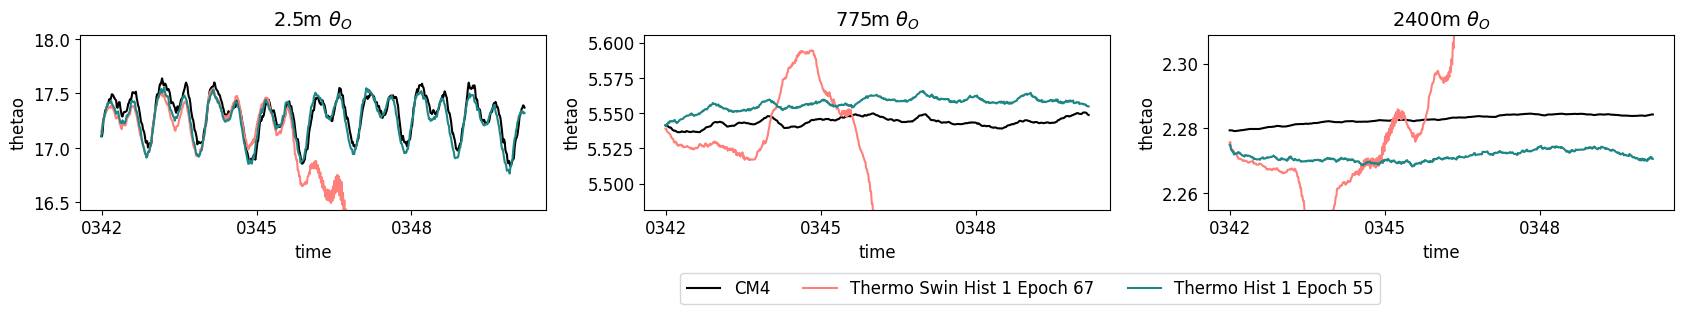

In [44]:
import matplotlib.pyplot as plt
import os

shallow_levels = [2.5, 775, 2400]

num_shallow_levels = len(shallow_levels)

plt.rcParams.update({'font.size': 12})
num_plots = 0
for var in ['thetao']:
    if 'lev' in pred_dict[k]["ds_prediction"][var].coords:
        num_plots += num_shallow_levels  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 3  # Number of columns
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*3))
axes = axes.flatten()  # Flatten the 2D array of axes for easy access

plot_idx = 0  # Initialize plot index to track subplot positions

# Loop over each variable to plot its time series
for v in ['thetao']:
    if v == 'zos':
        # Handle 'zos' separately (no levels)
        ax = axes[plot_idx]
        profile_groundtruth[v].plot(ax=ax, label='CM4', c='k')

        for i, k in enumerate(pred_dict.keys()):
            if v in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][v].plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])

        # Adjust y-axis limits and formatting
        min_val, max_val = ax.get_ylim()
        ax.set_ylim(min_val - 0.05, max_val + 0.05)
        ax.set_title(f"{v}", fontsize=14)
        ax.set_xlabel('Time')
        ax.set_ylabel(var_list[v])

        plot_idx += 1  # Move to the next subplot

    else:
        # For other variables, loop over each level
        for lev in shallow_levels:
            ax = axes[plot_idx]
            profile_groundtruth[v].sel(lev=lev).plot(ax=ax, label='CM4', c='k')

            maxs, mins = ax.get_ylim()
            for i, k in enumerate(pred_dict.keys()):
                if v in pred_dict[k]["ls"]:
                    pred_dict[k]["profile_prediction"][v].sel(lev=lev).plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])

            if var == 'thetao':
                if lev > 1000:
                    ax.set_ylim(mins - 0.03, maxs + 0.03)
                elif lev > 500:
                    ax.set_ylim(mins - 0.07, maxs + 0.07)
                else:
                    ax.set_ylim(mins - 1.25, maxs + 1.25)
                ax.set_title(f"{lev}m "+r'$\theta_O$', fontsize=14)

            plot_idx += 1  # Move to the next subplot

            if plot_idx >= rows * cols:
                break  # Stop if the grid is full

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])  # Leave space on the right for the legend

# Create a single legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', ncols=3, bbox_to_anchor=(0.34, -0.03), fontsize=12)

# fig.suptitle("Time Series Plots", fontsize=24)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])
    
# Save the figure
output_file = os.path.join(output_path, "temp_timeseries_grid_shallow_skipped.png")
plt.savefig(output_file, bbox_inches='tight', dpi=600)
# plt.close(fig)

### OHC

In [45]:
def raw_ohc(ds):
    c_p = 3850 #J/(kg C) 
    rho_0 = 1025 #kg/m^3
    ohc = ds.thetao * c_p * rho_0 #C*J/(kg C)*kg/m^3 = J/m^3
    return ohc

def vertical_ohc(ds):
    ohc_raw = raw_ohc(ds)
    ohc_intz = ohc_raw.weighted(ds.dz).sum('lev')
    # multiply by area to get Joules
    ohc_intz = ohc_intz * ds.areacello
    
    return ohc_intz

ohc_truth = vertical_ohc(ds_groundtruth)
ohc_truth_timeseries = ohc_truth.sum(['x','y']).load()

for k in pred_dict.keys():
    pred_dict[k]["ohc_prediction"] = vertical_ohc(pred_dict[k]["ds_prediction"])
    pred_dict[k]["ohc_prediction_timeseries"] = pred_dict[k]["ohc_prediction"].sum(['x','y']).load()

<Figure size 640x480 with 0 Axes>

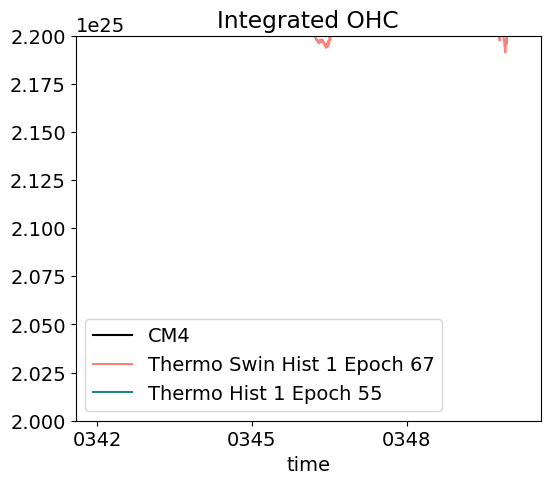

In [46]:
plt.clf()
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=[6, 5])
(ohc_truth_timeseries).plot(label='CM4', c='k')
for i, k in enumerate(pred_dict.keys()):
    (pred_dict[k]["ohc_prediction_timeseries"]).plot(label=pred_dict[k]["name"], c=clist[i])
plt.ylim(2e25, 2.2e25)
plt.title("Integrated OHC")
plt.legend()

plt.savefig(os.path.join(output_path, "ohc_timeseries.png"), bbox_inches='tight', dpi=600)

### Basin

In [47]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd

In [48]:
# %matplotlib inline
plt.rcParams.update({'font.size': 14})

In [49]:
data = ds_groundtruth
data = data.drop_vars(['lon','lat'])
data = data.transpose('time','lev',...)
for k in pred_dict.keys():
    pred_dict[k]["ds_prediction"] = pred_dict[k]["ds_prediction"].transpose('time','lev',...)

In [50]:
for k in pred_dict.keys():
    pred_dict[k]["ds_prediction"]['y'] = pred_dict[k]["ds_prediction"].y.assign_attrs(long_name='latitude')
    pred_dict[k]["ds_prediction"]['x']  = pred_dict[k]["ds_prediction"].x.assign_attrs(long_name='longitude')
    pred_dict[k]["ds_prediction"]['thetao'] = pred_dict[k]["ds_prediction"]['thetao'].assign_attrs(long_name = r"${\theta_O}$", units = r'$\degree C$')
    pred_dict[k]["ds_prediction"]['lev'] = pred_dict[k]["ds_prediction"]['lev'].assign_attrs(long_name = 'depth', units = 'm')
    if 'so' in pred_dict[k]["ls"]:
        pred_dict[k]["ds_prediction"]['so'] = pred_dict[k]["ds_prediction"]['so'].assign_attrs(long_name = r"${s}$", units = r"psu")
    if 'zos' in pred_dict[k]["ls"]:
        pred_dict[k]["ds_prediction"]['zos'] = pred_dict[k]["ds_prediction"]['zos'].assign_attrs(long_name = r"SSH", units = r"m")    
    if 'uo' in pred_dict[k]["ls"]:
        pred_dict[k]["ds_prediction"]['vo'] = pred_dict[k]["ds_prediction"]['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")
        pred_dict[k]["ds_prediction"]['uo'] = pred_dict[k]["ds_prediction"]['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")

data['y']  = data.y.assign_attrs(long_name='latitude')
data['x']  = data.x.assign_attrs(long_name='longitude')
data['thetao'] = data['thetao'].assign_attrs(long_name = r"${\theta_O}$", units = r'$\degree C$')
data['lev'] = data['lev'].assign_attrs(long_name = 'depth', units = 'm')
data['so'] = data['so'].assign_attrs(long_name = r"${s}$", units = r"psu")
data['zos'] = data['zos'].assign_attrs(long_name = r"SSH", units = r"m")    
data['vo'] = data['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")
data['uo'] = data['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")

upper_trend_truth:  5.506630240011757e+20
Thermo Swin Hist 1 Epoch 67  upper_trend_pred:  -3.475890515835867e+23
Thermo Hist 1 Epoch 55  upper_trend_pred:  5.470713721337688e+20
mid_trend_truth:  3.0988528635410153e+20
Thermo Swin Hist 1 Epoch 67  mid_trend_pred:  5.1989968416589845e+22
Thermo Hist 1 Epoch 55  mid_trend_pred:  1.112543439422839e+21
deep_trend_truth:  1.8951942353396622e+21
Thermo Swin Hist 1 Epoch 67  deep_trend_pred:  3.328438775176979e+23
Thermo Hist 1 Epoch 55  deep_trend_pred:  1.0394923438817065e+21


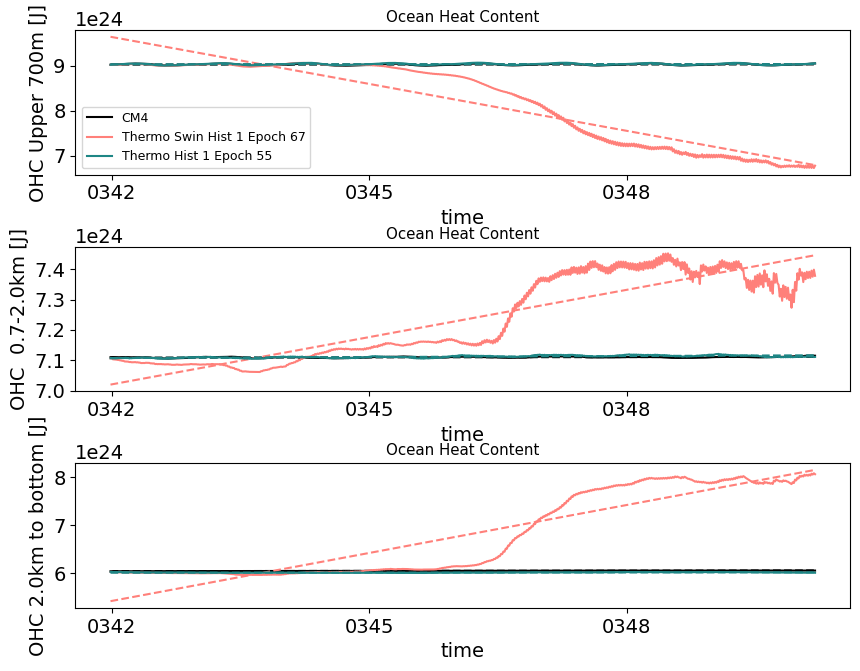

In [51]:
# Depth wise OHC
Days_to_Eq = 0
c_p = 3850 #J/(kg C)
rho_0 = 1025 #kg/m^3
fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})
plt.rcParams.update({'font.size': 9})

f = open(os.path.join(output_path, 'compare_info.txt'), 'a')


# Upper - CM4
OHC_truth_upper = ((data['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])
OHC_truth_upper.plot(ax = ax[0], label = 'CM4', c = 'k')
coeffs_OHC_ground_trend= np.polyfit(np.arange(OHC_truth_upper[Days_to_Eq:].size), OHC_truth_upper[Days_to_Eq:], 1)
pos, = ax[0].plot(OHC_truth_upper[Days_to_Eq:].time.data, np.arange(OHC_truth_upper[Days_to_Eq:].size)*coeffs_OHC_ground_trend[0] + coeffs_OHC_ground_trend[1],c = 'k', ls = '--')
# ax[0].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nUpper - CM4 Trend Slope : {coeffs_OHC_ground_trend[0]}')
CM4_upper = coeffs_OHC_ground_trend[0]
upper_trend_truth = coeffs_OHC_ground_trend[0]*73
print("upper_trend_truth: ", upper_trend_truth)

# Upper - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_upper"] = ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])
    pred_dict[k]["OHC_pred_upper"] = pred_dict[k]["OHC_pred_upper"].rename('OHC Upper 700m')
    pred_dict[k]["OHC_pred_upper"] = pred_dict[k]["OHC_pred_upper"].assign_attrs(units = 'J')
    pred_dict[k]["coeffs_OHC_pred_trend_upper"]= np.polyfit(np.arange(pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].size), pred_dict[k]["OHC_pred_upper"][Days_to_Eq:], 1)
    pred_dict[k]["OHC_pred_upper"].plot(ax = ax[0], label = pred_dict[k]["name"], c = clist[i])
    pos, = ax[0].plot(pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].time.data, np.arange(pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].size)*pred_dict[k]["coeffs_OHC_pred_trend_upper"][0] + pred_dict[k]["coeffs_OHC_pred_trend_upper"][1],c = clist[i], ls = '--')
    # ax[0].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]:.2e}', 
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
    #          fontsize=9, color=clist[i])
    f.write(f'\nUpper - {pred_dict[k]["name"]} Trend Slope : {pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]}')
    pred_dict[k]["upper_trend_pred"] = pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]*73
    print(pred_dict[k]["name"], " upper_trend_pred: ", pred_dict[k]["upper_trend_pred"])
    pred_dict[k]["total_trend_pred"] = pred_dict[k]["upper_trend_pred"]
    
ax[0].legend()
ax[0].set_title("Ocean Heat Content")


# Middle - CM4
OHC_truth_mid = ((data['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])
OHC_truth_mid.plot(ax = ax[1], label = 'CM4', c = 'k')
coeffs_OHC_ground_trend= np.polyfit(np.arange(OHC_truth_mid[Days_to_Eq:].size), OHC_truth_mid[Days_to_Eq:], 1)
pos, = ax[1].plot(OHC_truth_mid[Days_to_Eq:].time.data, np.arange(OHC_truth_mid[Days_to_Eq:].size)*coeffs_OHC_ground_trend[0] + coeffs_OHC_ground_trend[1],c = 'k', ls = '--')
# ax[1].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nMiddle - CM4 Trend Slope : {coeffs_OHC_ground_trend[0]}')
CM4_mid = coeffs_OHC_ground_trend[0]
mid_trend_truth = coeffs_OHC_ground_trend[0]*73
print("mid_trend_truth: ", mid_trend_truth)

# Middle - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_mid"] = ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])
    pred_dict[k]["OHC_pred_mid"] = pred_dict[k]["OHC_pred_mid"].rename('OHC  0.7-2.0km')
    pred_dict[k]["OHC_pred_mid"] = pred_dict[k]["OHC_pred_mid"].assign_attrs(units = 'J')
    pred_dict[k]["coeffs_OHC_pred_trend_mid"]= np.polyfit(np.arange(pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].size), pred_dict[k]["OHC_pred_mid"][Days_to_Eq:], 1)
    pred_dict[k]["OHC_pred_mid"].plot(ax = ax[1], label = pred_dict[k]["name"], c = clist[i])
    pos, = ax[1].plot(pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].time.data, np.arange(pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].size)*pred_dict[k]["coeffs_OHC_pred_trend_mid"][0] + pred_dict[k]["coeffs_OHC_pred_trend_mid"][1],c = clist[i], ls = '--')
    # ax[1].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]:.2e}', 
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
    #          fontsize=9, color=clist[i])
    f.write(f'\nMiddle - {pred_dict[k]["name"]} Trend Slope : {pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]}')
    pred_dict[k]["mid_trend_pred"] = pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]*73
    print(pred_dict[k]["name"], " mid_trend_pred: ", pred_dict[k]["mid_trend_pred"])
    pred_dict[k]["total_trend_pred"] += pred_dict[k]["mid_trend_pred"]
    
# ax[1].legend()
ax[1].set_title("Ocean Heat Content")

# Deep - CM4
OHC_truth_deep = ((data['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])
OHC_truth_deep.plot(ax = ax[2], label = 'CM4', c = 'k')
coeffs_OHC_ground_trend= np.polyfit(np.arange(OHC_truth_deep[Days_to_Eq:].size), OHC_truth_deep[Days_to_Eq:], 1)
pos, = ax[2].plot(OHC_truth_deep[Days_to_Eq:].time.data, np.arange(OHC_truth_deep[Days_to_Eq:].size)*coeffs_OHC_ground_trend[0] + coeffs_OHC_ground_trend[1],c = 'k', ls = '--')
# ax[2].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nDeep - CM4 Trend Slope : {coeffs_OHC_ground_trend[0]}')
CM4_deep = coeffs_OHC_ground_trend[0]
deep_trend_truth = coeffs_OHC_ground_trend[0]*73
print("deep_trend_truth: ", deep_trend_truth)

# Deep - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_deep"] = ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])
    pred_dict[k]["OHC_pred_deep"] = pred_dict[k]["OHC_pred_deep"].rename('OHC 2.0km to bottom')
    pred_dict[k]["OHC_pred_deep"] = pred_dict[k]["OHC_pred_deep"].assign_attrs(units = 'J')
    pred_dict[k]["coeffs_OHC_pred_trend_deep"]= np.polyfit(np.arange(pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].size), pred_dict[k]["OHC_pred_deep"][Days_to_Eq:], 1)
    pred_dict[k]["OHC_pred_deep"].plot(ax = ax[2], label = pred_dict[k]["name"], c = clist[i])
    pos, = ax[2].plot(pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].time.data, np.arange(pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].size)*pred_dict[k]["coeffs_OHC_pred_trend_deep"][0] + pred_dict[k]["coeffs_OHC_pred_trend_deep"][1],c = clist[i], ls = '--')
    # ax[2].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]:.2e}', 
    #      xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
    #      xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
    #      fontsize=9, color=clist[i])
    f.write(f'\nDeep - {pred_dict[k]["name"]} Trend Slope : {pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]}')
    
    pred_dict[k]["deep_trend_pred"] = pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]*73
    print(pred_dict[k]["name"], " deep_trend_pred: ", pred_dict[k]["deep_trend_pred"])
    pred_dict[k]["total_trend_pred"] += pred_dict[k]["deep_trend_pred"]
    
# ax[2].legend()
ax[2].set_title("Ocean Heat Content")
total_trend_truth = upper_trend_truth + mid_trend_truth + deep_trend_truth

f.write(f"\nCM4 Trend Ratio (Upper, Mid, Deep): {upper_trend_truth/total_trend_truth:.2f}, {mid_trend_truth/total_trend_truth:.2f}, {deep_trend_truth/total_trend_truth:.2f}")
for k in pred_dict.keys():
    f.write(f'\n{pred_dict[k]["name"]} Trend Ratio (Upper, Mid, Deep): {pred_dict[k]["upper_trend_pred"]/pred_dict[k]["total_trend_pred"]:.2f}, {pred_dict[k]["mid_trend_pred"]/pred_dict[k]["total_trend_pred"]:.2f}, {pred_dict[k]["deep_trend_pred"]/pred_dict[k]["total_trend_pred"]:.2f}')
# ax[0].annotate(f'OHC portion of trend (truth, pred): ({upper_trend_truth/total_trend_truth:.2f}, {upper_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
# ax[1].annotate(f'OHC portion of trend (truth, pred): ({mid_trend_truth/total_trend_truth:.2f}, {mid_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
# ax[2].annotate(f'OHC portion of trend (truth, pred): ({deep_trend_truth/total_trend_truth:.2f}, {deep_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
f.write("\n")
f.close()

plt.savefig(os.path.join(output_path, "OHC_Timeseries_depths"), bbox_inches='tight', dpi=600)

In [52]:
pd_data = []
pd_data.append({
    'Model': 'CM4',
    'Upper': CM4_upper,
    'Middle': CM4_mid,
    'Deep': CM4_deep
})

for k in pred_dict.keys():
    pd_data.append({
        'Model': pred_dict[k]["name"],
        'Upper': pred_dict[k]["coeffs_OHC_pred_trend_upper"][0],
        'Upper Slope Ratio': pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]/CM4_upper,
        'Middle': pred_dict[k]["coeffs_OHC_pred_trend_mid"][0],
        'Middle Slope Ratio': pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]/CM4_mid,
        'Deep': pred_dict[k]["coeffs_OHC_pred_trend_deep"][0],
        'Deep Slope Ratio': pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]/CM4_deep
    })

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(output_path, "depthwise_ohc_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


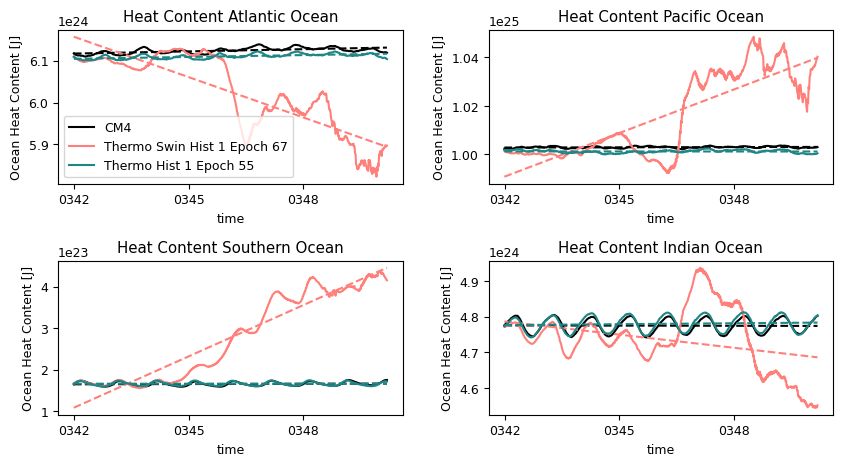

In [53]:
# Compute Basin Heat Content Time Series

f = open(os.path.join(output_path, 'compare_info.txt'), 'a')

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,data)

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
plt.rcParams.update({'font.size': 9})
ax_flat = ax.flatten()

CM4_regionwise_ohc = {}
CM4_regionwise_ohc['Model'] = 'CM4'
for j, k in enumerate(pred_dict.keys()):
    pred_dict[k]["regionwise_ohc"] = {}

for i, var in enumerate(list(masks.keys())):
    OHC = ((data['thetao']*c_p*rho_0*masks[var])*data['areacello']*data['dz']).sum(['x','y','lev'])
    OHC = OHC.rename('Ocean Heat Content')
    OHC = OHC.assign_attrs(units = 'J')
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    OHC.plot(ax = ax_flat[i], label = 'CM4',c = 'k')
    pos, = ax_flat[i].plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')
    # ax_flat[i].annotate(f'{coeffs_OHC_trend[0]:.2e}', 
    #          xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
    #          xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
    #          fontsize=9, color='k')
    f.write(f'\nOHC {var} CM4 Trend Slope : {coeffs_OHC_trend[0]}')
    CM4_regionwise_ohc[var] = coeffs_OHC_trend[0]
    for j, k in enumerate(pred_dict.keys()):
        OHC_pred = ((pred_dict[k]["ds_prediction"]['thetao']*c_p*rho_0*masks[var])*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])    
        OHC_pred = OHC_pred.rename('Ocean Heat Content')
        OHC_pred = OHC_pred.assign_attrs(units = 'J')    
        coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
        OHC_pred.plot(ax = ax_flat[i], label = pred_dict[k]["name"], c = clist[j])
        pos, = ax_flat[i].plot(OHC_pred.time.data, np.arange(OHC_pred.size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = clist[j], ls = '--')
        # ax_flat[i].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}', 
        #      xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
        #      xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
        #      fontsize=9, color=clist[j])
        f.write(f'\nOHC {var} {pred_dict[k]["name"]} Trend Slope : {coeffs_OHC_pred_trend[0]}')
        pred_dict[k]["regionwise_ohc"][var] = coeffs_OHC_pred_trend[0]
        
    if i == 0:
        ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")

f.write("\n")
f.close()
# plt.show()
plt.savefig(os.path.join(output_path, "OHC_Short"), bbox_inches='tight', dpi=600)

In [54]:
pd_data = []
pd_data.append(CM4_regionwise_ohc)


for k in pred_dict.keys():
    d = {}
    d['Model'] = pred_dict[k]["name"]
    for var in masks.keys():
        d[var] = pred_dict[k]["regionwise_ohc"][var]
        d[var+' Slope Ratio'] = pred_dict[k]["regionwise_ohc"][var]/CM4_regionwise_ohc[var]
    pd_data.append(d)

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(output_path, "regionwise_ohc_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

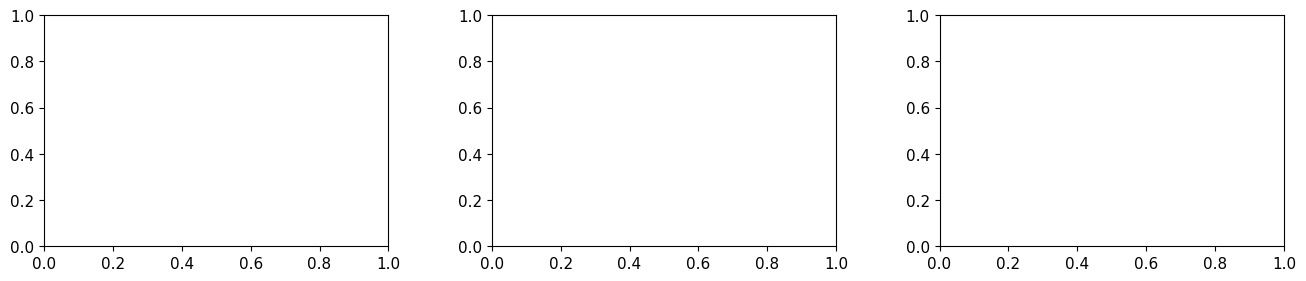

In [55]:
plt.clf()
plt.rcParams.update({'font.size': 11})

new_cmap = cm.cm.thermal 

new_cmap.set_bad('grey',.6)
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3
num_basins = 1
num_models = len(pred_dict) + 1  # Including CM4

# Create figure with appropriate layout
fig, ax = plt.subplots(num_basins, num_models, figsize=(16, 3), 
                       gridspec_kw={'width_ratios': [1]*num_models, 
                                    'height_ratios': [1]*num_basins, 
                                    'wspace': 0.3, 'hspace': 0.5})
ax = np.array(ax)  # Ensure ax is an array for easy indexing

# Set common color range for the colorbar
vmin, vmax = 0, None  # Adjust vmax based on expected range, if known


# Plot CM4 (original data)
da_ohc = data['thetao'] * c_p * rho_0 * data['dz'] 
section_mask = np.isnan(da_ohc).all('x').isel(time=0)
da_ohc_int_x = da_ohc.weighted(data['areacello']).sum('x').mean('time')
OHC_pred = da_ohc_int_x.where(~section_mask)
OHC_pred = OHC_pred.rename('Ocean Heat Content').assign_attrs(units='J')
OHC_pred['y'] = OHC_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
OHC_pred['lev'] = OHC_pred.lev.assign_attrs(long_name='depth', units='m')

im = OHC_pred.plot(ax=ax[0], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[0].invert_yaxis()
ax[0].set_title(f"CM4")
linear_piecewise_scale(1000, 5, ax=ax[0])
ax[0].axhline(1000, color='0.5', ls='--')
ax[0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# Plot predictions from other models
for j, (model_key, model_data) in enumerate(pred_dict.items(), start=1):
    da_ohc = model_data["ds_prediction"]['thetao'] * c_p * rho_0 * data['dz'] 
    section_mask = np.isnan(da_ohc).all('x').isel(time=0)
    da_ohc_int_x = da_ohc.weighted(data['areacello']).sum('x').mean('time')
    OHC_pred = da_ohc_int_x.where(~section_mask)
    OHC_pred = OHC_pred.rename('Ocean Heat Content').assign_attrs(units='J')
    OHC_pred['y'] = OHC_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
    OHC_pred['lev'] = OHC_pred.lev.assign_attrs(long_name='depth', units='m')

    im = OHC_pred.plot(ax=ax[j], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax[j].invert_yaxis()
    ax[j].set_title(f"{pred_dict[model_key]['name']}")
    linear_piecewise_scale(1000, 5, ax=ax[j])
    ax[j].axhline(1000, color='0.5', ls='--')
    ax[j].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# Add shared colorbar for each row
cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Ocean Heat Content (J)", fontsize=11)


plt.savefig(os.path.join(output_path, "OHC_Global_Profile"), bbox_inches='tight', dpi=600)
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cmocean as cm

plt.clf()
plt.rcParams.update({'font.size': 14})

# Define colormap
new_cmap = cm.cm.thermal 
new_cmap.set_bad('grey', .6)


num_basins = 1
num_models = len(pred_dict) + 1  # Including CM4

# Create figure with appropriate layout
fig, ax = plt.subplots(num_basins, num_models, figsize=(16, 3), 
                       gridspec_kw={'width_ratios': [1]*num_models, 
                                    'height_ratios': [1]*num_basins, 
                                    'wspace': 0.02, 'hspace': 0.5})
ax = np.array(ax)  # Ensure ax is an array for easy indexing

# Set common color range for the colorbar
vmin, vmax = 0, 30

# Plot CM4 (original data)
da_temp = data['thetao'] # Directly use temperature variable
section_mask = np.isnan(da_temp).all('x').isel(time=0)
da_temp_int_x = da_temp.weighted(data['areacello']).mean(['x', 'time'])
temp_pred = da_temp_int_x.where(~section_mask)
temp_pred = temp_pred.rename(r'$\theta_O$').assign_attrs(units=r'$\degree C$')
temp_pred['y'] = temp_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
temp_pred['lev'] = temp_pred.lev.assign_attrs(long_name='depth', units='m')

im = temp_pred.plot(ax=ax[0], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
CM4_temp_pred = temp_pred
ax[0].invert_yaxis()
ax[0].set_title("CM4", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[0])
ax[0].axhline(1000, color='0.5', ls='--')
ax[0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# Plot predictions from other models
for j, (model_key, model_data) in enumerate(pred_dict.items(), start=1):
    da_temp = model_data["ds_prediction"]['thetao']  # Use temperature variable
    section_mask = np.isnan(da_temp).all('x').isel(time=0)
    da_temp_int_x = da_temp.weighted(data['areacello']).mean(['x', 'time'])
    temp_pred = da_temp_int_x.where(~section_mask)
    temp_pred = temp_pred.rename(r'$\theta_O$').assign_attrs(units=r'$\degree C$')
    temp_pred['y'] = temp_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
    temp_pred['lev'] = temp_pred.lev.assign_attrs(long_name='depth', units='m')
    pred_dict[model_key]['temp_profile'] = temp_pred

    im = temp_pred.plot(ax=ax[j], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax[j].invert_yaxis()
    ax[j].set_title(f"{pred_dict[model_key]['name']}", fontsize=14)
    linear_piecewise_scale(1000, 5, ax=ax[j])
    ax[j].axhline(1000, color='0.5', ls='--')
    # ax[j].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
    ax[j].set_yticks([])
    ax[j].set_ylabel("")

# Add shared colorbar for each row
cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r"$\theta_O$ [$\degree C$]")

# plt.show()
plt.savefig(os.path.join(output_path, "Temperature_Global_Profile"), bbox_inches='tight', dpi=600)
plt.close()

In [ ]:
%matplotlib inline

In [ ]:
new_cmap = cm.cm.balance 
new_cmap.set_bad('grey', .6)
fig, ax = plt.subplots(1, 3, figsize=(16, 3), gridspec_kw={'width_ratios': [1, 1, 1], 
                                    'height_ratios': [1],
                                    'wspace': 0.02, 'hspace': 0.5})
vmin, vmax = -0.5, 0.5
for i, key in enumerate(pred_dict):
    im = (pred_dict[key]['temp_profile']-CM4_temp_pred).plot(ax=ax[i], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax[i].invert_yaxis()
    ax[i].set_title(f"{pred_dict[key]['name']} - CM4", fontsize=14)
    linear_piecewise_scale(1000, 5, ax=ax[i])
    ax[i].axhline(1000, color='0.5', ls='--')
    if i == 0:
        ax[i].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
    else:
        ax[i].set_yticks([])
        ax[i].set_ylabel("")

i=i+1
im = (pred_dict['pred_1']['temp_profile']-pred_dict['pred_2']['temp_profile']).plot(ax=ax[i], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[i].invert_yaxis()
ax[i].set_title(f"{pred_dict['pred_1']['name']} - {pred_dict['pred_2']['name']}", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[i])
ax[i].axhline(1000, color='0.5', ls='--')
ax[i].set_yticks([])
ax[i].set_ylabel("")
cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r"$\theta_O$ [$\degree C$]")

plt.savefig(os.path.join(output_path, "Temperature_Diff_Global_Profile"), bbox_inches='tight', dpi=600)
# plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cmocean as cm

plt.clf()
plt.rcParams.update({'font.size': 14})

# Define colormap
new_cmap = cm.cm.haline  # Salinity-specific colormap from cmocean
new_cmap.set_bad('grey', .6)

num_basins = 1
num_models = len(pred_dict) + 1  # Including CM4

# Create figure with appropriate layout
fig, ax = plt.subplots(num_basins, num_models, figsize=(16, 3), 
                       gridspec_kw={'width_ratios': [1]*num_models, 
                                    'height_ratios': [1]*num_basins, 
                                    'wspace': 0.02, 'hspace': 0.5})
ax = np.array(ax)  # Ensure ax is an array for easy indexing

# Set common color range for the colorbar
vmin, vmax = 33, 36  # Typical salinity range, adjust as needed

# Plot CM4 (original data)
da_salinity = data['so']  # Replace with salinity variable
section_mask = np.isnan(da_salinity).all('x').isel(time=0)
da_salinity_int_x = da_salinity.weighted(data['areacello']).mean(['x', 'time'])
salinity_pred = da_salinity_int_x.where(~section_mask)
salinity_pred = salinity_pred.rename(r'$S$').assign_attrs(units='psu')  # Salinity units
salinity_pred['y'] = salinity_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
salinity_pred['lev'] = salinity_pred.lev.assign_attrs(long_name='depth', units='m')

im = salinity_pred.plot(ax=ax[0], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
CM4_salinity_pred = salinity_pred
ax[0].invert_yaxis()
ax[0].set_title("CM4", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[0])
ax[0].axhline(1000, color='0.5', ls='--')
ax[0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# Plot predictions from other models
for j, (model_key, model_data) in enumerate(pred_dict.items(), start=1):
    da_salinity = model_data["ds_prediction"]['so']  # Replace with salinity variable
    section_mask = np.isnan(da_salinity).all('x').isel(time=0)
    da_salinity_int_x = da_salinity.weighted(data['areacello']).mean(['x', 'time'])
    salinity_pred = da_salinity_int_x.where(~section_mask)
    salinity_pred = salinity_pred.rename(r'$S$').assign_attrs(units='psu')
    salinity_pred['y'] = salinity_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
    salinity_pred['lev'] = salinity_pred.lev.assign_attrs(long_name='depth', units='m')
    pred_dict[model_key]['salinity_profile'] = salinity_pred

    im = salinity_pred.plot(ax=ax[j], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax[j].invert_yaxis()
    ax[j].set_title(f"{pred_dict[model_key]['name']}", fontsize=14)
    linear_piecewise_scale(1000, 5, ax=ax[j])
    ax[j].axhline(1000, color='0.5', ls='--')
    if j == 0:
        ax[j].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
    else:
        ax[j].set_yticks([])
        ax[j].set_ylabel("")

# Add shared colorbar for each row
cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r"$S$ [psu]")  # Salinity colorbar label in psu

# Save the figure
# plt.show()
plt.savefig(os.path.join(output_path, "Salinity_Global_Profile"), bbox_inches='tight', dpi=600)
plt.close()

In [ ]:
import cmocean as cm
import matplotlib.pyplot as plt
new_cmap = cm.cm.delta 
new_cmap.set_bad('grey', .6)
fig, ax = plt.subplots(1, 3, figsize=(16, 3), gridspec_kw={'width_ratios': [1, 1, 1], 
                                    'height_ratios': [1],
                                    'wspace': 0.02, 'hspace': 0.5})
vmin, vmax = -0.05, 0.05

i = 0

im = (pred_dict['pred_1']['salinity_profile']-CM4_salinity_pred).plot(ax=ax[i], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[i].invert_yaxis()
ax[i].set_title(f"{pred_dict['pred_1']['name']} - CM4", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[i])
ax[i].axhline(1000, color='0.5', ls='--')
ax[i].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

i=i+1
im = (pred_dict['pred_2']['salinity_profile']-CM4_salinity_pred).plot(ax=ax[i], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[i].invert_yaxis()
ax[i].set_title(f"{pred_dict['pred_2']['name']} - CM4", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[i])
ax[i].axhline(1000, color='0.5', ls='--')
# ax[i].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
ax[i].set_yticks([])
ax[i].set_ylabel("")

i=i+1
im = (pred_dict['pred_1']['salinity_profile']-pred_dict['pred_2']['salinity_profile']).plot(ax=ax[i], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[i].invert_yaxis()
ax[i].set_title(f"{pred_dict['pred_1']['name']} - {pred_dict['pred_2']['name']}", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[i])
ax[i].axhline(1000, color='0.5', ls='--')
# ax[i].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
ax[i].set_yticks([])
ax[i].set_ylabel("")

cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r"S [psu]")

plt.savefig(os.path.join(output_path, "Salinity_Diff_Global_Profile"), bbox_inches='tight', dpi=600)
# plt.show()
plt.close()

In [ ]:
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3
f = open(os.path.join(output_path, 'compare_info.txt'), 'a')

plt.rcdefaults()
fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})
plt.rcParams.update({'font.size': 9})

OHC = ((data['thetao']*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
OHC = OHC.rename('Ocean Heat Content')
OHC = OHC.assign_attrs(units = 'J')

for i, k in enumerate(pred_dict.keys()):
    OHC_pred = ((pred_dict[k]["ds_prediction"]['thetao']*c_p*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])    
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred = OHC_pred.assign_attrs(units = 'J')
    OHC_pred.plot(ax = ax[0], label = pred_dict[k]["name"], c = clist[i])
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
    pos, = ax[0].plot(OHC_pred.time.data, np.arange(OHC_pred.size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = clist[i], ls = '--')
    # ax[0].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}', 
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
    #          fontsize=9, color=clist[i])
    f.write(f'\nOHC {pred_dict[k]["name"]} Trend Slope : {coeffs_OHC_pred_trend[0]}')
    pred_dict[k]["OHC_slope"] = coeffs_OHC_pred_trend[0]
    
OHC.plot(ax = ax[0], label = 'CM4', c = 'k')
coeffs_OHC_trend= np.polyfit(np.arange(OHC.size), OHC, 1)
pos, = ax[0].plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')
# ax[0].annotate(f'{coeffs_OHC_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nOHC CM4 Trend Slope : {coeffs_OHC_trend[0]}')
CM4_ohc_slope = coeffs_OHC_trend[0]
ax[0].legend()


salinity = ((data['so']*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

for i, k in enumerate(pred_dict.keys()):
    if 'so' in pred_dict[k]["ls"]:
        salinity_pred = ((pred_dict[k]["ds_prediction"]['so']*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])    
        salinity_pred = salinity_pred.rename('Salinity')
        salinity_pred = salinity_pred.assign_attrs(units = 'g')
        salinity_pred.plot(ax = ax[1], label = pred_dict[k]["name"], c = clist[i])
        coeffs_salinity_pred_trend= np.polyfit(np.arange(salinity_pred.size), salinity_pred, 1)
        pos, = ax[1].plot(salinity_pred.time.data, np.arange(salinity_pred.size)*coeffs_salinity_pred_trend[0] + coeffs_salinity_pred_trend[1],c = clist[i], ls = '--')
        # ax[1].annotate(f'{coeffs_salinity_pred_trend[0]:.2e}', 
        #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
        #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
        #          fontsize=9, color=clist[i])
        f.write(f'\nSalinity {pred_dict[k]["name"]} Trend Slope : {coeffs_salinity_pred_trend[0]}')
        pred_dict[k]["salinity_slope"] = coeffs_salinity_pred_trend[0]
    
    
coeffs_salinity_trend= np.polyfit(np.arange(salinity.size), salinity, 1)
salinity.plot(ax = ax[1], label = 'CM4', c = 'k')
pos, = ax[1].plot(salinity.time.data, np.arange(salinity.size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')
# ax[1].annotate(f'{coeffs_salinity_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nSalinity CM4 Trend Slope : {coeffs_salinity_trend[0]}')
CM4_salinity_slope = coeffs_salinity_trend[0]
ax[1].set_ylim([5.8605e+22, 5.8635e+22])
f.write("\n")
f.close()

print(coeffs_OHC_trend[0]*73)
print(coeffs_salinity_trend[0]*73)
plt.savefig(os.path.join(output_path, "OHC_salinity"), bbox_inches='tight', dpi=600)


In [ ]:
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3
f = open(os.path.join(output_path, 'compare_info.txt'), 'a')

plt.rcdefaults()
fig, ax = plt.subplots(1,1,figsize=(10,3),gridspec_kw={'wspace': 0.25,'hspace':.5})
plt.rcParams.update({'font.size': 9})

OHC = ((data['thetao']*c_p*rho_0)*data['areacello']*data['dz']).sum(['x','y','lev'])    
OHC = OHC.rename('Ocean Heat Content')
OHC = OHC.assign_attrs(units = 'J')

for i, k in enumerate(pred_dict.keys()):
    OHC_pred = ((pred_dict[k]["ds_prediction"]['thetao']*c_p*rho_0)*pred_dict[k]["ds_prediction"]['areacello']*pred_dict[k]["ds_prediction"]['dz']).sum(['x','y','lev'])    
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred = OHC_pred.assign_attrs(units = 'J')
    OHC_pred.plot(ax = ax, label = pred_dict[k]["name"], c = clist[i])
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
    pos, = ax.plot(OHC_pred.time.data, np.arange(OHC_pred.size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = clist[i], ls = '--')
    # ax[0].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}', 
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]), 
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]), 
    #          fontsize=9, color=clist[i])
    f.write(f'\nOHC {pred_dict[k]["name"]} Trend Slope : {coeffs_OHC_pred_trend[0]}')
    pred_dict[k]["OHC_slope"] = coeffs_OHC_pred_trend[0]
    
OHC.plot(ax = ax, label = 'CM4', c = 'k')
coeffs_OHC_trend= np.polyfit(np.arange(OHC.size), OHC, 1)
pos, = ax.plot(OHC.time.data, np.arange(OHC.size)*coeffs_OHC_trend[0] + coeffs_OHC_trend[1],c = 'k', ls = '--')
# ax[0].annotate(f'{coeffs_OHC_trend[0]:.2e}', 
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]), 
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]), 
#              fontsize=9, color='k')
f.write(f'\nOHC CM4 Trend Slope : {coeffs_OHC_trend[0]}')
CM4_ohc_slope = coeffs_OHC_trend[0]
ax.legend()

f.close()
plt.savefig(os.path.join(output_path, "OHC"), bbox_inches='tight', dpi=600)


In [ ]:
pd_data = []
pd_data.append({
    'Model': 'CM4',
    'OHC': CM4_ohc_slope,
    'Salinity': CM4_salinity_slope,
})

for k in pred_dict.keys():
    pd_data.append({
        'Model': pred_dict[k]["name"],
        'OHC': pred_dict[k]["OHC_slope"],
        'OHC Slope Ratio': pred_dict[k]["OHC_slope"]/CM4_ohc_slope,
        'Salinity': pred_dict[k]["salinity_slope"],
        'Salinity Slope Ratio': pred_dict[k]["salinity_slope"]/CM4_salinity_slope
    })

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(output_path, "ohc_salinity_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

### ENSO

In [ ]:
clim =  data['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()
data_surface = data.sel(lev = slice(0,500))
for k in pred_dict.keys():
    pred_dict[k]["ds_prediction_surface"] = pred_dict[k]["ds_prediction"].sel(lev = slice(0,500))
    pred_dict[k]["clim_pred"] = pred_dict[k]["ds_prediction_surface"]['thetao'].groupby('time.dayofyear').mean().compute()

In [ ]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(190,240), y = slice(-5,5))
    area = area.sel(x = slice(190,240), y = slice(-5,5)).load()
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    # T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])
    T_clim = T_clim.weighted(area).mean(["x", "y"])

    return T_clim[window:]


In [ ]:
nino_true_compute_clim = NinoIndexComputeClim(data_surface['thetao'][:,0],data['areacello'])
nino_true_compute_clim = nino_true_compute_clim.rename('Nino 3.4')
nino_true_compute_clim = nino_true_compute_clim.assign_attrs(units = r'$\degree C$')

for k in pred_dict.keys():
    pred_dict[k]["nino_pred_compute_clim"] = NinoIndexComputeClim(pred_dict[k]["ds_prediction_surface"]['thetao'][:,0],pred_dict[k]["ds_prediction"]['areacello'])
    pred_dict[k]["nino_pred_compute_clim"] = pred_dict[k]["nino_pred_compute_clim"].rename('Nino 3.4')
    nino_pred_compute_clim = pred_dict[k]["nino_pred_compute_clim"].assign_attrs(units = r'$\degree C$')

In [ ]:
import numpy as np
day_max = int((np.argwhere(nino_true_compute_clim.values == np.nanmax(nino_true_compute_clim.values)) + 30).squeeze())
day_min = int((np.argwhere(nino_true_compute_clim.values == np.nanmin(nino_true_compute_clim.values)) + 30).squeeze())

In [ ]:
plt.rcParams.update({'font.size': 9})
plt.figure(figsize=[10, 5])
nino_true_compute_clim.plot(label = 'CM4', c = 'k')
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["nino_pred_compute_clim"].plot(label = pred_dict[k]["name"], c = clist[i])

ax = plt.gca()
ax.legend()
ax.set_title('Nino 3.4 Index')

plt.savefig(os.path.join(output_path, "Climatology"), bbox_inches='tight', dpi=600)

### PDFs

In [ ]:
plt.rcParams.update({'font.size': 9})
if not os.path.isdir(os.path.join(output_path, "PDFs")):
    os.makedirs(os.path.join(output_path, "PDFs"))


for v in ['uo', 'vo', 'thetao', 'so', 'zos']:
    print("v: ", v)
    plt.clf()
    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=[8, 6])
    min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(ds_groundtruth[v], bins=150, density=True, range=(min_val, max_val))
    
    for i, k in enumerate(pred_dict.keys()):
        if v in pred_dict[k]["ls"]:
            pdf_net, bins_net = np.histogram(pred_dict[k]["ds_prediction"][v], bins=bins_true, density=True, range=(min_val, max_val))
            plt.semilogy(bins_net[:-1], pdf_net, label = pred_dict[k]["name"], c = clist[i], lw=2)

    plt.semilogy(bins_true[:-1], true_pdf, label='CM4', color='k', lw=2, ls='--')
    plt.legend()
    plt.xlabel(var_list[v])
    plt.ylabel(r"${p(}$" + var_list[v].split(" $")[0] + "${)}$")
    if v != 'thetao':
        plt.ylim(
            [
                true_pdf.min(),
                true_pdf.max(),
            ]
        )
        if v == 'KE':
            plt.xlim([0, 2500])
    else:
        plt.ylim(
            [
                0.01,
                true_pdf.max(),
            ]
        )
        plt.xlim([-2, 32])
    plt.savefig(os.path.join(output_path, "PDFs", f"{v}.png"), bbox_inches='tight', dpi=600)
    # plt.show()

In [ ]:
import matplotlib
from matplotlib.ticker import MaxNLocator
plt.rcParams.update({'font.size': 9})
# Create a figure
fig = plt.figure(figsize=(24, 15))
plt.rc('axes', titlesize=30)     # fontsize of the axes title
plt.rc('axes', labelsize=30)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('legend', fontsize=20)    # legend fontsize
plt.rc('figure', titlesize=30)
# Manual positioning using add_axes with uniform width and height
width = 0.22
height = 0.3

# Top row: 3 plots, evenly spaced horizontally
axs = [
    fig.add_axes([0.05, 0.55, width, height]),  # First plot in top row
    fig.add_axes([0.38, 0.55, width, height]),  # Second plot in top row
    fig.add_axes([0.71, 0.55, width, height])   # Third plot in top row
]

# Bottom row: 2 plots centered, manually positioned
axs += [
    fig.add_axes([0.22, 0.1, width, height]),  # First plot in bottom row
    fig.add_axes([0.54, 0.1, width, height])  # Second plot in bottom row
]

# Plot PDFs
for i, v in enumerate(['thetao', 'so', 'zos', 'uo', 'vo']):
    min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(data[v], bins=150, density=True, range=(min_val, max_val))
    axs[i].semilogy(bins_true[:-1], true_pdf, label="CM4", color='k', lw=8)
    
    for j, k in enumerate(pred_dict.keys()):
        if v in pred_dict[k]["ls"]:
            pdf_net, bins_net = np.histogram(pred_dict[k]["ds_prediction"][v], bins=150, density=True, range=(min_val, max_val))
            axs[i].semilogy(bins_net[:-1], pdf_net, label=pred_dict[k]["name"], color=clist[j], lw=2)  
        
    axs[i].xaxis.set_major_locator(MaxNLocator(5,prune = 'both'))
    if i == 0:
        axs[i].legend()
    axs[i].set_xlabel(r""+ data[v].long_name+ "["+data[v].units +"]")
    axs[i].set_ylabel(r"${p(}$" + data[v].long_name+ " " + "${)}$")

    if v not in ['thetao', 'SSH']:
        axs[i].set_ylim([min(true_pdf.min(),pdf_net.min())+1e-5, true_pdf.max()])
    else:
        axs[i].set_ylim([1e-3, true_pdf.max()])
matplotlib.style.use('default')

# Save or show the figure
# plt.show()
plt.savefig(os.path.join(output_path, "PDF_Plots_Short"), bbox_inches='tight', dpi=600)


### Metrics

In [ ]:
#Drake Passage Full Depth 
day_start = -103
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = False

N_days = 100
for i, region in enumerate(['Drake Passage', 'Atlantic']):
    for k in pred_dict.keys():
        pred_dict[k][region] = {"mae_mean": 0, "cor_mean": 0}
        for j in range(N_days):

            bounds = regions[region]
            var = 'thetao'
            if surface:
                level_slice = slice(0,1000)
            else:
                level_slice = slice(None)

            depth_slice = data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
            wet = np.array(xr.where(np.isnan(depth_slice),False,True))
            area = data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']
            area = area.values.transpose()[wet]

            depth_slice_pred = pred_dict[k]["ds_prediction"][var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')
            mae = np.abs(depth_slice_pred - depth_slice)
            mae =( mae*data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum(['y','lev'])/(data['areacello'].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'])*data['dz']).sum()
            mae = mae.assign_attrs(long_name = 'MAE', units = r"${^oC}$")
            pred_dict[k][region]["mae_mean"] += 1/N_days*mae.values
            cor = (area*depth_slice_pred.values[wet].flatten()*depth_slice.values[wet].flatten()).sum()/np.sqrt((area*depth_slice_pred.values[wet].flatten()**2).sum()*(area*depth_slice.values[wet].flatten()**2).sum())
            pred_dict[k][region]["cor_mean"] += 1/N_days*cor

In [ ]:
for k in pred_dict.keys():
    print(pred_dict[k]['Drake Passage'])
    print(pred_dict[k]['Atlantic'])
    
# Create a list of dictionaries for the DataFrame
pd_data = []
for k in pred_dict.keys():
    drake = pred_dict[k]['Drake Passage']
    atlantic = pred_dict[k]['Atlantic']
    pd_data.append({
        'Prediction': pred_dict[k]["name"],
        'Drake_Passage_MAE': drake['mae_mean'],
        'Drake_Passage_COR': drake['cor_mean'],
        'Atlantic_MAE': atlantic['mae_mean'],
        'Atlantic_COR': atlantic['cor_mean']
    })

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(output_path, "predictions_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

### Maps

This works for two predictions only

In [ ]:
keys = list(pred_dict.keys())
# assert len(keys) >= 2, "Maps supported by atleast two keys"
if len(keys) != 2:
    print("Maps only support two models for now!!! Using the first two keys")
key1 = keys[0]
key2 = keys[1]

In [ ]:
#Drake Passage Full Depth 
new_cmap = cm.cm.thermal 

new_cmap.set_bad('grey',.6)
plt.rcParams.update({'font.size': 9})

day_start = 597
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = False
fig, ax = plt.subplots(2,3,figsize=(10,6),gridspec_kw={'width_ratios': [1,1,1], 'height_ratios': [.9,.9], 'wspace': 0.25,'hspace':.4})

for i, region in enumerate(['Drake Passage', 'Atlantic']):
    bounds = regions[region]
    var = 'thetao'
    if surface:
        level_slice = slice(0,1000)
    else:
        level_slice = slice(None)
    
    depth_slice = data[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice = depth_slice.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    depth_slice['y']  = depth_slice.y.assign_attrs(long_name='latitude')

    max_val = np.ceil(depth_slice.max()).values
    
    depth_slice.plot(ax=ax[i,0],add_colorbar=False, cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,0].invert_yaxis()
    ax[i,0].set_title('CM4')
    linear_piecewise_scale(1000,5,ax =ax[i,0])
    ax[i,0].axhline(1000, color='0.5', ls='--')
    ax[i,0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    depth_slice_pred = pred_dict[key1]["ds_prediction"][var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice_pred = depth_slice_pred.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    pred_plot = depth_slice_pred.plot(ax=ax[i,1],add_colorbar=False,cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,1].invert_yaxis()
    ax[i,1].set_ylabel('')
    ax[i,1].set_title(pred_dict[key1]["name"])
    linear_piecewise_scale(1000,5,ax =ax[i,1])
    ax[i,1].axhline(1000, color='0.5', ls='--')
    ax[i,1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    depth_slice_pred = pred_dict[key2]["ds_prediction"][var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
    depth_slice_pred = depth_slice_pred.assign_attrs(long_name = data[var].long_name, units = r"^oC")
    pred_plot = depth_slice_pred.plot(ax=ax[i,2],add_colorbar=False,cmap = new_cmap, vmin = -2.5,vmax = max_val)
    ax[i,2].invert_yaxis()
    ax[i,2].set_ylabel('')
    ax[i,2].set_title(pred_dict[key2]["name"])
    linear_piecewise_scale(1000,5,ax =ax[i,2])
    ax[i,2].axhline(1000, color='0.5', ls='--')
    ax[i,2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.125+.45*i, 0.015, 0.29])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(pred_dict[key2]["ds_prediction"][var].long_name,rotation = 90)
    
fig.text(0.02, 0.5, "Drake Passage" + r" lon: 70${^o}W$" , ha='center', fontsize=14, rotation=90)
fig.text(0.02, 0.125, region + r" lon: 30${^o}W$", ha='center', fontsize=14, rotation=90)    


plt.savefig(os.path.join(output_path, "Depth_Profiles_Short.png"), bbox_inches='tight', dpi=600)


In [ ]:
from xarrayutils.plotting import box_plot
plt.rcParams.update({'font.size': 9})
fig,axs = plt.subplot_mosaic([['time series','map'],['nino_true','nina_true'],['nino_pred','nina_pred'],['nino_pred_temp','nina_pred_temp'],['colorbar','colorbar']],figsize = (10,9),per_subplot_kw = {'map':dict(projection=ccrs.Robinson(190))},gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.3,.3,.3,.05], 'wspace': 0.25,'hspace':.5})

pred_dict[key1]["nino_pred_compute_clim"].plot(label = pred_dict[key1]["name"], c = clist[0],ax = axs['time series'])
pred_dict[key2]["nino_pred_compute_clim"].plot(label = pred_dict[key2]["name"], c = clist[1],ax = axs['time series'])

nino_true_compute_clim.plot(label = 'CM4', c = 'k',ax = axs['time series'])
nino_true_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])
nino_true_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].set_xlabel('')
axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(pred_dict[key2]["ds_prediction_surface"]['time'][day_start],pred_dict[key2]["ds_prediction_surface"]['time'][day_start+window])
times = pred_dict[key2]["ds_prediction"]['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = pred_dict[key1]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
pred_clim_to_remove_temp = pred_dict[key2]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove_temp['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (pred_dict[key1]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred_temp = (pred_dict[key2]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove_temp.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile_pred_temp = tropics_profile_pred_temp.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp['x'] = tropics_profile_pred_temp['x'].assign_attrs(units = r"${^o}$")

tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_true'].set_title('Nino Conditions CM4')
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_pred'].set_title(f'Nino Conditions {pred_dict[key1]["name"]}')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(ax = axs['nino_pred_temp'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_pred_temp'].set_title(f'Nino Conditions {pred_dict[key2]["name"]}')
# axs['nino_pred_temp'].set_xlabel('')
axs['nino_pred_temp'].invert_yaxis()



day_start = day_min
window = 3

time_slice = slice(pred_dict[key2]["ds_prediction"]['time'][day_start],pred_dict[key2]["ds_prediction"]['time'][day_start+window])
times = pred_dict[key2]["ds_prediction"]['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = pred_dict[key1]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
pred_clim_to_remove_temp = pred_dict[key2]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove_temp['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (pred_dict[key1]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred_temp = (pred_dict[key2]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove_temp.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile_pred_temp = tropics_profile_pred_temp.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp['x'] = tropics_profile_pred_temp['x'].assign_attrs(units = r"${^o}$")

tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nina_true'].set_title('Nina Conditions CM4')
axs['nina_true'].set_xlabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nina_pred'].set_title(f'Nina Conditions {pred_dict[key1]["name"]}')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(ax = axs['nina_pred_temp'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
                        "orientation": "horizontal",
                        "shrink": 0.3,
                        "extend": "both",
                    })
axs['nina_pred_temp'].set_title(f'Nina Conditions {pred_dict[key2]["name"]}')
# axs['nina_pred_temp'].set_xlabel('')
axs['nina_pred_temp'].invert_yaxis()

# maybe define this centrally and use for all plots from this variable?
bound_east = 118 # i think these are outdated?
bound_west = 260
bound_north = 5
bound_south = -5
# nino 3.4 box
nino_east = 190
nino_west = 240

axs['map'].set_extent([70, 320 ,-25, 25], crs=ccrs.PlateCarree())    
axs['map'].stock_img()
axs['map'].coastlines(color='0.3', lw=0.5)
gl = axs['map'].gridlines(draw_labels=True, color='0.4')
box_plot(
    [bound_east, bound_west, bound_south, bound_north], 
    ax=axs['map'],
    color='orange',
    transform=ccrs.PlateCarree(),
    label='Full Profile'
)
box_plot(
    [nino_east, nino_west, bound_south, bound_north], 
    ax=axs['map'],
    color='red',
    ls='--',
    transform=ccrs.PlateCarree(),
    label='Niño 3.4'
)
axs['map'].legend(bbox_to_anchor=[.5, -.5], loc='center',ncol = 2)

plt.savefig(os.path.join(output_path, "Nino_Figure_Short_with_map.png"), bbox_inches='tight', dpi=600)


In [ ]:
from xarrayutils.plotting import box_plot
plt.rcParams.update({'font.size': 14})
fig,axs = plt.subplot_mosaic([['time series','nino_true'],['nino_pred','nino_pred_temp'],['colorbar','colorbar']],figsize = (16,7),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5,.05], 'wspace': 0.25,'hspace':.5})

pred_dict[key1]["nino_pred_compute_clim"].plot(label = pred_dict[key1]["name"], c = clist[0],ax = axs['time series'])
pred_dict[key2]["nino_pred_compute_clim"].plot(label = pred_dict[key2]["name"], c = clist[1],ax = axs['time series'])

nino_true_compute_clim.plot(label = 'CM4', c = 'k',ax = axs['time series'])
nino_true_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])
# nino_true_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].set_xlabel('')
# axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(pred_dict[key2]["ds_prediction_surface"]['time'][day_start],pred_dict[key2]["ds_prediction_surface"]['time'][day_start+window])
times = pred_dict[key2]["ds_prediction"]['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = pred_dict[key1]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
pred_clim_to_remove_temp = pred_dict[key2]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove_temp['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (pred_dict[key1]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred_temp = (pred_dict[key2]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove_temp.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile_pred_temp = tropics_profile_pred_temp.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp['x'] = tropics_profile_pred_temp['x'].assign_attrs(units = r"${^o}$")

tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_true'].set_title('Nino Conditions CM4', fontsize=14)
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_pred'].set_title(f'Nino Conditions {pred_dict[key1]["name"]}', fontsize=14)
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(ax = axs['nino_pred_temp'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
                        "orientation": "horizontal",
                        "shrink": 0.3,
                        "extend": "both",
                    })
axs['nino_pred_temp'].set_title(f'Nino Conditions {pred_dict[key2]["name"]}', fontsize=14)
# axs['nino_pred_temp'].set_xlabel('')
axs['nino_pred_temp'].invert_yaxis()

plt.savefig(os.path.join(output_path, "Nino_Figure_Short_without_map.png"), bbox_inches='tight', dpi=600)


In [ ]:
from xarrayutils.plotting import box_plot
plt.rcParams.update({'font.size': 14})
fig,axs = plt.subplot_mosaic([['time series','nina_true'],['nina_pred','nina_pred_temp'],['colorbar','colorbar']],figsize = (16,7),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5,.05], 'wspace': 0.25,'hspace':.5})

pred_dict[key1]["nino_pred_compute_clim"].plot(label = pred_dict[key1]["name"], c = clist[0],ax = axs['time series'])
pred_dict[key2]["nino_pred_compute_clim"].plot(label = pred_dict[key2]["name"], c = clist[1],ax = axs['time series'])

nino_true_compute_clim.plot(label = 'CM4', c = 'k',ax = axs['time series'])
# nino_true_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])
nino_true_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].set_xlabel('')
axs['time series'].legend(ncol=2)
# axs['time series'].set_title('Nino 3.4 Index')


day_start = day_min
window = 3

time_slice = slice(pred_dict[key2]["ds_prediction"]['time'][day_start],pred_dict[key2]["ds_prediction"]['time'][day_start+window])
times = pred_dict[key2]["ds_prediction"]['time'][day_start:day_start+window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = pred_dict[key1]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
pred_clim_to_remove_temp = pred_dict[key2]["clim_pred"].sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove_temp['time'] = times

tropics_profile = (data_surface['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5))-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (pred_dict[key1]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred_temp = (pred_dict[key2]["ds_prediction_surface"]['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove_temp.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile_pred_temp = tropics_profile_pred_temp.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units = r"${^oC}$")
tropics_profile_pred_temp['x'] = tropics_profile_pred_temp['x'].assign_attrs(units = r"${^o}$")

tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nina_true'].set_title('Nina Conditions CM4', fontsize=14)
axs['nina_true'].set_xlabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nina_pred'].set_title(f'Nina Conditions {pred_dict[key1]["name"]}', fontsize=14)
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(ax = axs['nina_pred_temp'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
                        "orientation": "horizontal",
                        "shrink": 0.3,
                        "extend": "both",
                    })
axs['nina_pred_temp'].set_title(f'Nina Conditions {pred_dict[key2]["name"]}', fontsize=14)
# axs['nina_pred_temp'].set_xlabel('')
axs['nina_pred_temp'].invert_yaxis()


# maybe define this centrally and use for all plots from this variable?
# bound_east = 118 # i think these are outdated?
# bound_west = 260
# bound_north = 5
# bound_south = -5
# # nino 3.4 box
# nino_east = 190
# nino_west = 240

# axs['map'].set_extent([70, 320 ,-25, 25], crs=ccrs.PlateCarree())    
# axs['map'].stock_img()
# axs['map'].coastlines(color='0.3', lw=0.5)
# gl = axs['map'].gridlines(draw_labels=True, color='0.4')
# box_plot(
#     [bound_east, bound_west, bound_south, bound_north], 
#     ax=axs['map'],
#     color='orange',
#     transform=ccrs.PlateCarree(),
#     label='Full Profile'
# )
# box_plot(
#     [nino_east, nino_west, bound_south, bound_north], 
#     ax=axs['map'],
#     color='red',
#     ls='--',
#     transform=ccrs.PlateCarree(),
#     label='Niño 3.4'
# )
# axs['map'].legend(bbox_to_anchor=[.5, -.4], loc='center',ncol = 2)

plt.savefig(os.path.join(output_path, "Nina_Figure_Short_without_map.png"), bbox_inches='tight', dpi=600)


In [ ]:
def ohc_map(ohc_intz):
    # return last 5 years - first 5 years
    return ohc_intz.isel(time=slice(-73, None)).mean('time')-ohc_intz.isel(time=slice(0, 73)).mean('time')

ohc_truth_map = ohc_map(ohc_truth).load()
ohc_truth_map['y']  = ohc_truth_map.y.assign_attrs(long_name='latitude', units = r'$\degree$')
ohc_truth_map['x']  = ohc_truth_map.x.assign_attrs(long_name='longitude', units = r'$\degree$')
ohc_truth_map = ohc_truth_map.assign_attrs(units = 'J').rename('Ocean Heat Content')
pred_dict[key1]["ohc_prediction_map"] = ohc_map(pred_dict[key1]["ohc_prediction"]).load()
pred_dict[key1]["ohc_prediction_map"] = pred_dict[key1]["ohc_prediction_map"].assign_attrs(units = 'J').rename('Ocean Heat Content')
pred_dict[key1]["ohc_prediction_map"]['y']  = pred_dict[key1]["ohc_prediction_map"].y.assign_attrs(long_name='latitude', units = r'$\degree$')
pred_dict[key1]["ohc_prediction_map"]['x']  = pred_dict[key1]["ohc_prediction_map"].x.assign_attrs(long_name='longitude', units = r'$\degree$')
pred_dict[key2]["ohc_prediction_map"] = ohc_map(pred_dict[key2]["ohc_prediction"]).load()
pred_dict[key2]["ohc_prediction_map"] =pred_dict[key2]["ohc_prediction_map"].assign_attrs(units = 'J').rename('Ocean Heat Content')
pred_dict[key2]["ohc_prediction_map"]['y']  = pred_dict[key2]["ohc_prediction_map"].y.assign_attrs(long_name='latitude', units = r'$\degree$')
pred_dict[key2]["ohc_prediction_map"]['x']  = pred_dict[key2]["ohc_prediction_map"].x.assign_attrs(long_name='longitude', units = r'$\degree$')

plt.clf()
fig, ax = plt.subplots(1,4,figsize=(12,3),layout="constrained",gridspec_kw={'width_ratios': [0.98,0.98,0.98,0.06], 'height_ratios': [1], 'wspace': 0.04,'hspace':.4})
plt.rcParams.update({'font.size': 9})

new_cmap = cm.cm.balance 
mask = ds_groundtruth.wetmask.isel(lev=0)
ohc_truth_map = ohc_truth_map.where(mask)
pred_dict[key1]["ohc_prediction_map"] = pred_dict[key1]["ohc_prediction_map"].where(mask)
pred_dict[key2]["ohc_prediction_map"] = pred_dict[key2]["ohc_prediction_map"].where(mask)
new_cmap.set_bad('grey',.6)

vmax = 2.5e19

ohc_truth_map.plot(ax=ax[0], vmax=vmax, cmap=new_cmap, add_colorbar=False)
ax[0].set_title('CM4')

pred_dict[key1]["ohc_prediction_map"].plot(ax=ax[1], vmax=vmax, cmap=new_cmap, add_colorbar=False)
ax[1].set_title(pred_dict[key1]["name"])

pred_dict[key2]["ohc_prediction_map"].plot(ax=ax[2], vmax=vmax, cmap=new_cmap, cbar_ax=ax[3])
ax[2].set_title(pred_dict[key2]["name"])

plt.savefig(os.path.join(output_path, "OHC_map.png"), bbox_inches='tight', dpi=600)

In [ ]:
(pred_dict[key2]["ohc_prediction_map"] - pred_dict[key1]["ohc_prediction_map"]).plot(vmax=1e19)
plt.title(f'{pred_dict[key2]["name"]} - {pred_dict[key1]["name"]}')
plt.savefig(os.path.join(output_path, "OHC_diff_map.png"), bbox_inches='tight', dpi=600)
# plt.show()

In [ ]:
# OHC Map + Bias
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator


Days_to_Eq = 0
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
zeta_joules_factor = 1e21  # Conversion factor to ZJ

plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(2, 3, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()},
                        gridspec_kw={'wspace': 0.02, 'hspace': 0.23})
axs = axs.flatten()

# Define a common plotting function for Cartesian lat-lon grids
def plot_ohc(ax, ohc_data, title, i):
    # Configure colormap and set color for NaN values (land)
    colormap = cmocean.cm.thermal  # Using thermal colormap from cmocean
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0)) 
    mean = ohc_data.mean().compute().item()
    std = ohc_data.std().compute().item()
    vmin = mean-std
    vmax = mean+std
    im = ax.pcolormesh(
        ohc_data['x'], ohc_data['y'], ohc_data,
        shading='auto', cmap=colormap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.set_title(title, fontsize=14)
    # Set longitude and latitude labels
    gl = ax.gridlines(draw_labels=True, color='0.4', linestyle='--', alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im

def plot_diff_ohc(ax, ohc_data, gt_ohc_data, title, i):
    # Configure colormap and set color for NaN values (land)
    colormap = cmocean.cm.balance  # Using thermal colormap from cmocean
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0)) 
    bias_ohc = ohc_data - gt_ohc_data
    im = ax.pcolormesh(
        bias_ohc['x'], bias_ohc['y'], bias_ohc,
        shading='auto', cmap=colormap, transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.set_title(title, fontsize=14)
    # Set longitude and latitude labels
    gl = ax.gridlines(draw_labels=True, color='0.4', linestyle='--', alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 4:
        gl.left_labels = False
    return im

# Calculate Ocean Heat Content for different scenarios and convert to Zeta Joules
titles = ["CM4", pred_dict[key1]["name"], pred_dict[key2]["name"]]
bias_titles = [pred_dict[key1]["name"] + " Bias", pred_dict[key2]["name"] + " Bias"]
datasets = [data, pred_dict[key1]["ds_prediction"], pred_dict[key2]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds['thetao']).all('lev').isel(time=5)
    OHC_pred = (
        (ds['thetao'][Days_to_Eq:] * c_p * rho_0 / zeta_joules_factor)
        .weighted(ds['areacello'] * ds['dz']).sum(['lev'])
        .compute() 
    ).mean('time')
    OHC_pred = OHC_pred.where(~section_mask)
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred['y'] = OHC_pred.y.assign_attrs(long_name='latitude', units=r"${^o}$")
    OHC_pred['x'] = OHC_pred.x.assign_attrs(long_name='longitude', units=r"${^o}$")
    OHC_pred = OHC_pred.assign_attrs(units='ZJ')
    
    if i == 0:
        gt_ohc = OHC_pred
    elif i == 1:
        pred1_ohc = OHC_pred
    elif i == 2:
        pred2_ohc = OHC_pred

    # Plot using the Cartesian lat-lon grid
    im = plot_ohc(ax, OHC_pred, title, i)

# Add colorbar
cbar = fig.colorbar(im, ax=axs[:3], orientation='vertical', fraction=0.01, pad=0.02)
cbar.set_label("Ocean Heat Content [ZJ]", fontsize=14)

im = plot_diff_ohc(axs[4], pred1_ohc, gt_ohc, bias_titles[0], 4)
im = plot_diff_ohc(axs[5], pred2_ohc, gt_ohc, bias_titles[1], 5)

# Add colorbar
cbar = fig.colorbar(im, ax=axs[3:], orientation='vertical', fraction=0.01, pad=0.02)
cbar.set_label("Ocean Heat Content [ZJ]", fontsize=14)

fig.delaxes(axs[3])

# Save or display the plot
# plt.savefig(os.path.join(output_path, "OHC_Global_map.png"), bbox_inches='tight', dpi=600)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator


Days_to_Eq = 0
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(2, 3, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()},
                        gridspec_kw={'wspace': 0.02, 'hspace': 0.23})
axs = axs.flatten()

# Define a common plotting function for Cartesian lat-lon grids
def plot_sst(ax, sst_data, title, i):
    colormap = cmocean.cm.thermal
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0)) 
    mean = sst_data.mean().compute().item()
    std = sst_data.std().compute().item()
    vmin = mean-std
    vmax = mean+std
    im = ax.pcolormesh(
        sst_data['x'], sst_data['y'], sst_data,
        shading='auto', cmap=colormap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color='0.4', linestyle='--', alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im

def plot_diff_sst(ax, sst_data, gt_sst_data, title, i):
    colormap = cmocean.cm.balance
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0)) 
    sst_bias = sst_data - gt_sst_data
    im = ax.pcolormesh(
        sst_bias['x'], sst_bias['y'], sst_bias,
        shading='auto', cmap=colormap, transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color='0.4', linestyle='--', alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 4:
        gl.left_labels = False
    return im

# Calculate Sea Surface Temperature (SST) for different scenarios
titles = ["CM4", pred_dict[key1]["name"], pred_dict[key2]["name"]]
bias_titles = [pred_dict[key1]["name"] + " Bias", pred_dict[key2]["name"] + " Bias"]
datasets = [data, pred_dict[key1]["ds_prediction"], pred_dict[key2]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds['thetao']).isel(lev=0).isel(time=5)
    SST_pred = ds['thetao'].isel(lev=0).mean('time')
    SST_pred = SST_pred.where(~section_mask)
    SST_pred = SST_pred.rename("2.5m "+r'$\theta_O$')
    SST_pred['y'] = SST_pred.y.assign_attrs(long_name='latitude', units=r"${^o}$")
    SST_pred['x'] = SST_pred.x.assign_attrs(long_name='longitude', units=r"${^o}$")
    SST_pred = SST_pred.assign_attrs(units=r'$\degree C$')
    
    if i == 0:
        gt_sst = SST_pred
    elif i == 1:
        pred1_sst = SST_pred
    elif i == 2:
        pred2_sst = SST_pred

    # Plot using the Cartesian lat-lon grid
    im = plot_sst(ax, SST_pred, title, i)

# Add colorbar for SST plots
cbar = fig.colorbar(im, ax=axs[:3], orientation='vertical', fraction=0.01, pad=0.02)
cbar.set_label(r'$\theta_O$ [$\degree C$]', fontsize=14)

# Plot biases for SST
im = plot_diff_sst(axs[4], pred1_sst, gt_sst, bias_titles[0], 4)
im = plot_diff_sst(axs[5], pred2_sst, gt_sst, bias_titles[1], 5)

# Add colorbar for bias plots
cbar = fig.colorbar(im, ax=axs[3:], orientation='vertical', fraction=0.01, pad=0.02)
cbar.set_label(r'$\theta_O$ [$\degree C$]', fontsize=14)

# Remove the empty axis
fig.delaxes(axs[3])

# Save or display the plot
plt.savefig(os.path.join(output_path, "SST_Global_map.png"), bbox_inches='tight', dpi=600)
# plt.show()

In [ ]:
def detrend_and_remove_climatology(ds, var='zos'):    
    # Detrend the data
    poly_coeffs = ds[var].polyfit(dim='time', deg=1)
    trend = xr.polyval(ds['time'], poly_coeffs.polyfit_coefficients).compute()
    
    # Remove the trend from the original data
    ssh_detrended = ds[var] - trend

    # Compute the climatology on the detrended data
    climatology = ssh_detrended.groupby('time.dayofyear').mean('time').compute()

    # Remove the seasonal cycle (climatology) from the detrended data
    day_of_year = ssh_detrended['time'].dt.dayofyear
    ssh_final = (ssh_detrended - climatology.sel(dayofyear=day_of_year)).compute()
    
    return ssh_final, climatology, trend

In [ ]:
with ProgressBar():
    ssh_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth, 'zos')
    if 'zos' in pred_dict[key1]["ls"]:
        ssh_prediction_temp, _, _ = detrend_and_remove_climatology(pred_dict[key1]["ds_prediction"], 'zos')
    else:
        ssh_prediction_temp = ssh_groundtruth * 0
    if 'zos' in pred_dict[key2]["ls"]:
        ssh_prediction_all, _, _ = detrend_and_remove_climatology(pred_dict[key2]["ds_prediction"], 'zos')
    else:
        ssh_prediction_all = ssh_groundtruth * 0

In [ ]:
with ProgressBar():
    sst_2_5_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=2.5), 'thetao')
    sst_2_5_prediction_temp, _, _ = detrend_and_remove_climatology(pred_dict[key1]["ds_prediction"].sel(lev=2.5), 'thetao')
    sst_2_5_prediction_all, _, _ = detrend_and_remove_climatology(pred_dict[key2]["ds_prediction"].sel(lev=2.5), 'thetao')
    
with ProgressBar():
    sst_550_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=550), 'thetao')
    sst_550_prediction_temp, _, _ = detrend_and_remove_climatology(pred_dict[key1]["ds_prediction"].sel(lev=550), 'thetao')
    sst_550_prediction_all, _, _ = detrend_and_remove_climatology(pred_dict[key2]["ds_prediction"].sel(lev=550), 'thetao')
    
with ProgressBar():
    sst_1400_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=1400), 'thetao')
    sst_1400_prediction_temp, _, _ = detrend_and_remove_climatology(pred_dict[key1]["ds_prediction"].sel(lev=1400), 'thetao')
    sst_1400_prediction_all, _, _ = detrend_and_remove_climatology(pred_dict[key2]["ds_prediction"].sel(lev=1400), 'thetao')

In [ ]:
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(2,2,figsize=(16,6),layout="constrained",gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5], 'wspace': 0.05,'hspace':.05})

# ssh_groundtruth_ts = (ssh_groundtruth*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])
# ssh_prediction_temp_ts = (ssh_prediction_temp*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])
# ssh_prediction_all_ts = (ssh_prediction_all*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])

ssh_groundtruth_ts = ssh_groundtruth.weighted(ds_groundtruth.areacello).mean(["x","y"])
ssh_prediction_temp_ts = ssh_prediction_temp.weighted(ds_groundtruth.areacello).mean(["x","y"])
ssh_prediction_all_ts = ssh_prediction_all.weighted(ds_groundtruth.areacello).mean(["x","y"])

ssh_groundtruth_ts = ssh_groundtruth_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')
ssh_prediction_all_ts = ssh_prediction_all_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')
ssh_prediction_temp_ts = ssh_prediction_temp_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')

ssh_prediction_all_ts.plot(ax = axs[0,0],label = pred_dict[key2]["name"], c = clist[0])
ssh_prediction_temp_ts.plot(ax = axs[0,0],label = pred_dict[key1]["name"], c = clist[1])
ssh_groundtruth_ts.plot(ax = axs[0,0], label = 'CM4', c= 'k')
axs[0,0].legend(ncol=2,loc = 'lower right')
axs[0,0].set_xlabel('')

count = 0
for depth in [2.5,  550, 1400]:
    if count == 0:
        ax = axs[1,0]
        anoms = sst_2_5_groundtruth
        anoms_all = sst_2_5_prediction_all
        anoms_temp = sst_2_5_prediction_temp
    elif count == 1:
        ax = axs[0,1]
        anoms = sst_550_groundtruth
        anoms_all = sst_550_prediction_all
        anoms_temp = sst_550_prediction_temp
    else:
        ax = axs[1,1]
        anoms = sst_1400_groundtruth
        anoms_all = sst_1400_prediction_all
        anoms_temp = sst_1400_prediction_temp

    
    anoms_time_series = anoms.weighted(ds_groundtruth['areacello']).mean(['x','y'])
    anoms_all_time_series = anoms_all.weighted(ds_groundtruth['areacello']).mean(['x','y'])
    anoms_temp_time_series = anoms_temp.weighted(ds_groundtruth['areacello']).mean(['x','y'])

    anoms_time_series = anoms_time_series.assign_attrs(long_name = r"$\theta_O$ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')
    anoms_all_time_series = anoms_all_time_series.assign_attrs(long_name = r"$\theta_O $ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')
    anoms_temp_time_series = anoms_temp_time_series.assign_attrs(long_name = r"$\theta_O $ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')

    count += 1

    anoms_all_time_series.plot(ax = ax,label = pred_dict[key2]["name"], c = clist[0])
    anoms_temp_time_series.plot(ax = ax,label = pred_dict[key1]["name"], c = clist[1])
    anoms_time_series.plot(ax = ax, label = 'CM4', c= 'k')
    ax.set_xlabel('')
    ax.set_title('')

plt.savefig(os.path.join(output_path, "anomalies_SSH_temp_timeseries.png"), bbox_inches='tight',dpi = 600)


In [ ]:
ssh_groundtruth = ssh_groundtruth.assign_attrs(long_name = r'SSH $\sigma$', units = 'm').rename(r'SSH $\sigma$')
ssh_prediction_all = ssh_prediction_all.assign_attrs(long_name = r'SSH $\sigma$', units = 'm').rename(r'SSH $\sigma$')
ssh_prediction_temp = ssh_prediction_temp.assign_attrs(long_name = r'SSH $\sigma$', units = 'm').rename(r'SSH $\sigma$')

sst_2_5_groundtruth = sst_2_5_groundtruth.assign_attrs(long_name = r"$\theta_O$ $\sigma$ 2.5m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 2.5m")
sst_2_5_prediction_temp = sst_2_5_prediction_temp.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 2.5m", units = r"$^oC$").rename(r"$\theta_O $ $\sigma$ 2.5m")
sst_2_5_prediction_all = sst_2_5_prediction_all.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 2.5m", units = r"$^oC$").rename(r"$\theta_O $ $\sigma$ 2.5m")

sst_550_groundtruth = sst_550_groundtruth.assign_attrs(long_name = r"$\theta_O$ $\sigma$ 550m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 550m")
sst_550_prediction_temp = sst_550_prediction_temp.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 550m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 550m")
sst_550_prediction_all = sst_550_prediction_all.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 550m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 550m")

sst_1400_groundtruth = sst_1400_groundtruth.assign_attrs(long_name = r"$\theta_O$ $\sigma$ 1400m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 1400m")
sst_1400_prediction_temp = sst_1400_prediction_temp.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 1400m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 1400m")
sst_1400_prediction_all = sst_1400_prediction_all.assign_attrs(long_name = r"$\theta_O $ $\sigma$ 1400m", units = r"$^oC$").rename(r"$\theta_O$ $\sigma$ 1400m")


In [ ]:
def plot_map(anoms, anoms_all, anoms_temp, name):
    new_cmap = cm.cm.thermal 
    
    new_cmap.set_bad('grey',.6)
    
    vmin = 0
    vmax = np.nanmax(anoms.std('time'))/2
    fig, ax = plt.subplots(3,1,figsize=(5,8),layout="constrained",gridspec_kw={'width_ratios': [1], 'height_ratios': [.9,.9,.9], 'wspace': 0.05,'hspace':.05})
        
    anoms_std = anoms.std('time').assign_attrs(units = 'm')
    anoms_std['latitude']  = ohc_truth_map.y.assign_attrs(long_name='latitude', units = r'$\degree$')
    anoms_std['longitude']  = ohc_truth_map.x.assign_attrs(long_name='longitude', units = r'$\degree$')
    anoms_std.plot(ax=ax[0],add_colorbar=True, cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[0].set_title('CM4')
    
    anoms_temp.std('time').assign_attrs(units = 'm').plot(ax=ax[1],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[1].set_title(pred_dict[key1]["name"])
    
    anoms_all.std('time').assign_attrs(units = 'm').plot(ax=ax[2],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[2].set_title(pred_dict[key2]["name"])
    

    plt.savefig(os.path.join(output_path, name), bbox_inches='tight',dpi = 600)

In [ ]:
plot_map(ssh_groundtruth, ssh_prediction_all, ssh_prediction_temp, name='SSH_var_Map')

In [ ]:
def plot_3x3_map(anoms_list, anoms_all_list, anoms_temp_list, name):
    new_cmap = cm.cm.thermal 
    
    new_cmap.set_bad('grey',.6)
    
    fig, ax = plt.subplots(3,3,figsize=(16,8),layout="constrained",gridspec_kw={'width_ratios': [.9, .9, .9], 'height_ratios': [.9,.9,.9], 'wspace': 0.05,'hspace':.05})
    ax_flat = ax.flatten()

    for i, depth in enumerate(["2.5", "550", "1400"]):
        anoms = anoms_list[i]
        anoms_all = anoms_all_list[i]
        anoms_temp = anoms_temp_list[i]

        vmin = 0
        vmax = np.nanmax(anoms.std('time'))/2
        
        anoms_std = anoms.std('time').assign_attrs(units = 'm')
        anoms_std['latitude']  = ohc_truth_map.y.assign_attrs(long_name='latitude', units = r'$\degree$')
        anoms_std['longitude']  = ohc_truth_map.x.assign_attrs(long_name='longitude', units = r'$\degree$')
        
        anoms_std.assign_attrs(long_name = r"$\theta_O$ $\sigma$ {0}m".format(depth), units = r"$^oC$").plot(ax=ax_flat[i],add_colorbar=True, cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i].set_title('CM4')
        
        anoms_temp.assign_attrs(long_name = r"$\theta_O$ $\sigma$ {0}m".format(depth), units = r"$^oC$").std('time').plot(ax=ax_flat[i+3],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i+3].set_title(pred_dict[key1]["name"])
        
        anoms_all.assign_attrs(long_name = r"$\theta_O$ $\sigma$ {0}m".format(depth), units = r"$^oC$").std('time').plot(ax=ax_flat[i+6],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i+6].set_title(pred_dict[key2]["name"])

    plt.savefig(os.path.join(output_path, name), bbox_inches='tight',dpi = 600)

In [ ]:
plot_3x3_map(
    [sst_2_5_groundtruth, sst_550_groundtruth, sst_1400_groundtruth], 
    [sst_2_5_prediction_all, sst_550_prediction_all, sst_1400_prediction_all], 
    [sst_2_5_prediction_temp, sst_550_prediction_temp, sst_1400_prediction_temp], "Temps_var_Map")